# Diseño DSGE Semi-estructural - Jupyter Notebook

## 📋 Estructura por Bloques (Sin Clases)

### **BLOQUE 1: Configuración y Setup**
```python
# Imports y configuración general
# Parámetros del modelo (diccionarios simples)
# Paths y configuración de archivos
# Configuración de matplotlib/warnings

In [1]:
import subprocess
import os

# Cambiar al directorio donde está el archivo .ipynb si es necesario
# os.chdir("ruta/donde/esta/tu/notebook")

# Ejecutar el comando
subprocess.run([
    'jupyter', 'nbconvert', '--to', 'html', 
    'semi-dsge IV.ipynb', 
    '--output', r'C:\Users\Usuario\Downloads\semi-dsge.html'
])

CompletedProcess(args=['jupyter', 'nbconvert', '--to', 'html', 'semi-dsge IV.ipynb', '--output', 'C:\\Users\\Usuario\\Downloads\\semi-dsge.html'], returncode=4294967295)

In [2]:
# ==========================================
# BLOQUE 1: SETUP Y CONFIGURACIÓN
# ==========================================

# Imports esenciales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import beta, norm, invgamma
import warnings
warnings.filterwarnings('ignore')

print("📦 Librerías cargadas correctamente")

# ==========================================
# CONFIGURACIÓN DE ARCHIVOS
# ==========================================

# Paths de datos (ajustar según tu estructura)
data_paths = {
    'crudo': '../data/raw/crudo.csv',
    'diarias': '../data/raw/series_diarias.xlsx', 
    'mensuales': '../data/raw/series_mensuales.xlsx',
    'trimestrales': '../data/raw/series_trimestrales.xlsx',
    'potencial': '../data/raw/pib_potencial_espana.csv'
}

print("📁 Paths configurados")

# ==========================================
# PARÁMETROS DEL MODELO
# ==========================================

# Parámetros estructurales (valores iniciales para estimación)
# PARÁMETROS AJUSTADOS PARA ESPAÑA
params = {
    # ======================================
    # CURVA IS (MEJORADA PARA ESPAÑA)
    # ======================================
    'is_persistence': 0.70,        # ↑ Alta persistencia (rigideces estructurales)
    'is_forward': 0.20,            # NUEVO: Expectativas forward-looking
    'is_interest_rate': 0.25,      # Sensibilidad tipos (hipotecas variables)
    'is_demand_eu': 0.40,          # ↑ Demanda UE crítica (60% exportaciones)
    'is_demand_usa': 0.05,         # Demanda USA (bajo)
    'is_reer': 0.12,               # ↑ Competitividad (turismo importante)
    'is_fiscal': 0.30,             # NUEVO: Multiplicador fiscal (fondos NGEU)
    'is_credit': 0.15,             # NUEVO: Condiciones crédito
    'is_tourism': 0.10,            # NUEVO: Sector turístico (12% PIB)
    
    # ======================================
    # PHILLIPS NO-TRANSABLES (Servicios)
    # ======================================
    'phillips_nt_backward': 0.65,  # ↑ Alta persistencia (rigidez salarial)
    'phillips_nt_forward': 0.25,   # Expectativas
    'phillips_nt_gap': 0.25,       # Sensibilidad brecha (mercado dual)
    'phillips_nt_cost': 0.15,      # NUEVO: Costes marginales
    
    # ======================================
    # PHILLIPS TRANSABLES (Bienes)
    # ======================================
    'phillips_t_backward': 0.45,   # Persistencia (menor que NT)
    'phillips_t_forward': 0.30,    # Expectativas
    'phillips_t_gap': 0.20,        # Sensibilidad brecha
    'phillips_t_exchange': 0.25,   # Pass-through tipo cambio
    'phillips_t_foreign': 0.30,    # Inflación externa
    'phillips_t_oil': 0.15,        # Precios petróleo
    
    # ======================================
    # TAYLOR RULE BCE
    # ======================================
    'taylor_smoothing': 0.85,      # Alto suavizado BCE
    'taylor_inflation': 1.50,      # Taylor principle
    'taylor_output': 0.50,         # Respuesta output gap
    'r_neutral_spain': 1.00,       # Tipo neutral España
    'inflation_target': 2.00,      # Objetivo BCE
    
    # ======================================
    # OKUN LAW
    # ======================================
    'okun_persistence': 0.85,      # ↑ Histéresis muy alta España
    'okun_sensitivity': 0.45,      # Sensibilidad crecimiento
    'nairu': 13.0,                 # NAIRU promedio histórico
    
    # ======================================
    # SHOCKS (Persistencia AR1)
    # ======================================
    'rho_demand': 0.60,
    'rho_supply_nt': 0.40,
    'rho_supply_t': 0.30,
    'rho_monetary': 0.25,
    'rho_uip': 0.70,
    'rho_unemployment': 0.50,
    'rho_risk_premium': 0.85,      # NUEVO
    
    # ======================================
    # VARIANZAS SHOCKS
    # ======================================
    'sigma_demand': 0.010,
    'sigma_supply_nt': 0.005,
    'sigma_supply_t': 0.008,
    'sigma_monetary': 0.002,
    'sigma_uip': 0.015,
    'sigma_unemployment': 0.003,
    
    # ======================================
    # PESOS INFLACIÓN (INE 2021)
    # ======================================
    'weight_services': 0.42,       # Servicios (no-transables)
    'weight_goods_core': 0.33,     # Bienes industriales (transables)
    'weight_food': 0.15,           # Alimentos
    'weight_energy': 0.10          # Energía
}

print(f"⚙️  Parámetros actualizados: {len(params)} parámetros")
print("✅ Calibración específica para España implementada")

# ==========================================
# PRIORS BAYESIANOS
# ==========================================

priors = {
    # Curva IS
    'is_alpha_1': {'dist': 'beta', 'mean': 0.50, 'std': 0.10},
    'is_alpha_2': {'dist': 'beta', 'mean': 0.25, 'std': 0.08},
    'is_alpha_3': {'dist': 'beta', 'mean': 0.20, 'std': 0.06},
    'is_alpha_4': {'dist': 'beta', 'mean': 0.15, 'std': 0.05},
    'is_alpha_5': {'dist': 'beta', 'mean': 0.10, 'std': 0.04},
    'is_alpha_6': {'dist': 'norm', 'mean': -0.10, 'std': 0.05},
    'is_alpha_7': {'dist': 'beta', 'mean': 0.05, 'std': 0.03},
    
    # Phillips Curve NT
    'alpha_1': {'dist': 'beta', 'mean': 0.25, 'std': 0.08},
    'alpha_2': {'dist': 'beta', 'mean': 0.30, 'std': 0.10},
    'alpha_3': {'dist': 'beta', 'mean': 0.15, 'std': 0.06},
    'alpha_4': {'dist': 'beta', 'mean': 0.20, 'std': 0.08},
    
    # Phillips Curve T
    'beta_1': {'dist': 'beta', 'mean': 0.15, 'std': 0.06},
    'beta_2': {'dist': 'beta', 'mean': 0.10, 'std': 0.05},
    'beta_3': {'dist': 'beta', 'mean': 0.45, 'std': 0.12},
    'beta_4': {'dist': 'beta', 'mean': 0.30, 'std': 0.10},
    
    # Taylor Rule
    'gamma_1': {'dist': 'beta', 'mean': 0.85, 'std': 0.06},
    'gamma_2': {'dist': 'norm', 'mean': 1.65, 'std': 0.20},
    'gamma_3': {'dist': 'beta', 'mean': 0.18, 'std': 0.06},
    
    # UIP
    'theta': {'dist': 'beta', 'mean': 0.30, 'std': 0.10},
    'delta_1': {'dist': 'beta', 'mean': 0.25, 'std': 0.08},
    'delta_2': {'dist': 'beta', 'mean': 0.40, 'std': 0.12},
    
    # Okun
    'tau_1': {'dist': 'beta', 'mean': 0.35, 'std': 0.08},
    'tau_2': {'dist': 'beta', 'mean': 0.85, 'std': 0.06},
    'tau_4': {'dist': 'beta', 'mean': 0.05, 'std': 0.02},
    
    # Pesos
    'weight_core': {'dist': 'beta', 'mean': 0.70, 'std': 0.04},
    'weight_nt_in_core': {'dist': 'beta', 'mean': 0.65, 'std': 0.05},
    'weight_food': {'dist': 'beta', 'mean': 0.20, 'std': 0.03},
    'weight_energy': {'dist': 'beta', 'mean': 0.10, 'std': 0.02},
    'beta_energy_oil': {'dist': 'beta', 'mean': 0.25, 'std': 0.08},
    
    # Persistencia
    'rho_demand': {'dist': 'beta', 'mean': 0.60, 'std': 0.15},
    'rho_cost_nt': {'dist': 'beta', 'mean': 0.40, 'std': 0.12},
    'rho_cost_t': {'dist': 'beta', 'mean': 0.30, 'std': 0.10},
    'rho_monetary': {'dist': 'beta', 'mean': 0.25, 'std': 0.10},
    'rho_uip': {'dist': 'beta', 'mean': 0.70, 'std': 0.10},
    'rho_unemployment': {'dist': 'beta', 'mean': 0.50, 'std': 0.15}
}

print(f"📊 Priors configurados: {len(priors)} distribuciones")

# ==========================================
# VARIANZAS DE SHOCKS (valores iniciales)
# ==========================================

shock_variances = {
    'sigma_demand': 0.008,
    'sigma_cost_nt_persistent': 0.003,
    'sigma_cost_nt_transitory': 0.002,
    'sigma_cost_t_persistent': 0.004,
    'sigma_cost_t_transitory': 0.002,
    'sigma_monetary': 0.005,
    'sigma_uip': 0.012,
    'sigma_unemployment': 0.013,
    'sigma_food': 0.011,
    'sigma_energy': 0.015
}

print(f"📈 Varianzas de shocks: {len(shock_variances)} tipos")

# ==========================================
# CONFIGURACIÓN MATPLOTLIB
# ==========================================

plt.style.use('default')
plt.rcParams.update({
    'figure.figsize': (12, 8),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10
})

print("🎨 Matplotlib configurado")

# ==========================================
# VERIFICACIÓN FINAL
# ==========================================

print("\n" + "="*50)
print("✅ BLOQUE 1 COMPLETADO")
print("="*50)
print(f"📋 Resumen:")
print(f"   • Parámetros modelo: {len(params)}")
print(f"   • Priors bayesianos: {len(priors)}")
print(f"   • Varianzas shocks: {len(shock_variances)}")
print(f"   • Archivos datos: {len(data_paths)}")
print("="*50)

c:\Users\Usuario\anaconda3\envs\tftimeseriesII\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
c:\Users\Usuario\anaconda3\envs\tftimeseriesII\lib\site-packages\numpy\.libs\libopenblas.EL2C6PLE4ZYW3ECEVIV3OXXGRN2NRFM2.gfortran-win_amd64.dll
c:\Users\Usuario\anaconda3\envs\tftimeseriesII\lib\site-packages\numpy\.libs\libopenblas.XWYDX2IKJW2NMTWSFYNGFUWKQU3LYTCZ.gfortran-win_amd64.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


📦 Librerías cargadas correctamente
📁 Paths configurados
⚙️  Parámetros actualizados: 44 parámetros
✅ Calibración específica para España implementada
📊 Priors configurados: 35 distribuciones
📈 Varianzas de shocks: 10 tipos
🎨 Matplotlib configurado

✅ BLOQUE 1 COMPLETADO
📋 Resumen:
   • Parámetros modelo: 44
   • Priors bayesianos: 35
   • Varianzas shocks: 10
   • Archivos datos: 5


In [3]:
# ==========================================
# GESTIÓN DE SHOCKS ESTRUCTURALES (NUEVO)
# ==========================================

class ShockProcesses:
    """
    Gestión de shocks del modelo
    Todos siguen AR(1): ε_t = ρ·ε_{t-1} + η_t
    """
    
    def __init__(self, params):
        self.params = params
        
        # Estado actual de todos los shocks
        self.current_shocks = {
            'demand': 0.0,
            'supply_nt': 0.0,
            'supply_t': 0.0,
            'monetary': 0.0,
            'uip': 0.0,
            'unemployment': 0.0,
            'risk_premium': 0.0
        }
    
    def update(self, t, innovations=None):
        """
        Actualiza todos los shocks en período t
        
        Args:
            t: período actual
            innovations: dict con innovaciones (None = aleatorias)
        
        Returns:
            dict con valores actualizados de shocks
        """
        
        if innovations is None:
            # Generar innovaciones aleatorias
            innovations = {
                'demand': np.random.normal(0, self.params.get('sigma_demand', 0.01)),
                'supply_nt': np.random.normal(0, self.params.get('sigma_supply_nt', 0.005)),
                'supply_t': np.random.normal(0, self.params.get('sigma_supply_t', 0.008)),
                'monetary': np.random.normal(0, self.params.get('sigma_monetary', 0.002)),
                'uip': np.random.normal(0, self.params.get('sigma_uip', 0.015)),
                'unemployment': np.random.normal(0, self.params.get('sigma_unemployment', 0.003)),
                'risk_premium': np.random.normal(0, 0.005)
            }
        
        # Actualizar cada shock (proceso AR1)
        for shock_name in self.current_shocks.keys():
            rho_key = f'rho_{shock_name}'
            rho = self.params.get(rho_key, 0.5)
            
            self.current_shocks[shock_name] = (
                rho * self.current_shocks[shock_name] +
                innovations.get(shock_name, 0.0)
            )
        
        return self.current_shocks
    
    def reset(self):
        """Reinicia todos los shocks a cero"""
        for shock_name in self.current_shocks.keys():
            self.current_shocks[shock_name] = 0.0

# Inicializar gestor de shocks
shock_manager = ShockProcesses(params)

print("✅ Sistema de gestión de shocks implementado")
print(f"   Shocks gestionados: {len(shock_manager.current_shocks)}")

✅ Sistema de gestión de shocks implementado
   Shocks gestionados: 7



### **BLOQUE 2: Carga y Limpieza de Datos**
```python
# Funciones de carga de datos
# Limpieza y transformación básica
# Validación rápida de datos
# Merge de datasets

In [4]:
# ==========================================
# BLOQUE 2: CARGA Y LIMPIEZA DE DATOS
# ==========================================

def load_potential_gdp_data():
    """
    Cargar estimaciones del PIB potencial español desde archivo CSV
    """
    print("📊 Cargando estimaciones PIB potencial español...")
    
    try:
        # Cargar archivo CSV con estimaciones del PIB potencial
        potential_data = pd.read_csv('../data/raw/pib_potencial_espana.csv', sep=";", encoding='utf-8-sig')
        
        print(f"✅ Datos cargados: {len(potential_data)} observaciones")
        print(f"📅 Período: {potential_data['date'].iloc[0]} a {potential_data['date'].iloc[-1]}")
        
        # Verificar columnas requeridas
        required_cols = ['date', 'gdp_real', 'gdp_potential', 'output_gap', 
                        'potential_growth', 'tfp_trend', 'tfp_cycle', 'nairu', 
                        'employment_potential']
        
        missing_cols = [col for col in required_cols if col not in potential_data.columns]
        if missing_cols:
            print(f"⚠️ Columnas faltantes: {missing_cols}")
            return None
            
        # Convertir fechas
        potential_data['date'] = pd.to_datetime(potential_data['date'])
        potential_data.set_index('date', inplace=True)
        
        # Estadísticas básicas
        print(f"📊 PIB potencial actual: {potential_data['gdp_potential'].iloc[-1]:.0f}")
        print(f"📊 Brecha producto actual: {potential_data['output_gap'].iloc[-1]:.2f}%")
        print(f"📊 NAIRU actual: {potential_data['nairu'].iloc[-1]:.1f}%")
        
        return potential_data
        
    except Exception as e:
        print(f"❌ Error cargando PIB potencial: {e}")
        return None
    
    
def load_and_process_data():
    """Carga y procesa todos los datos siguiendo tu metodología original"""
    
    print("🔄 Cargando archivos...")
    
    # Cargar archivos
    try:
        df_crudo = pd.read_csv(data_paths['crudo'])
        df_diarias = pd.read_excel(data_paths['diarias'])
        df_mensuales = pd.read_excel(data_paths['mensuales'])
        df_trimestrales = pd.read_excel(data_paths['trimestrales'])
        print("✅ Archivos cargados correctamente")
    except FileNotFoundError as e:
        print(f"❌ Error: No se encontró {e.filename}")
        return None
    
    print("🧹 Limpiando datos...")
    
    # Limpiar datos (eliminar segunda fila)
    df_diarias = df_diarias.drop(df_diarias.index[0]).reset_index(drop=True)
    df_mensuales = df_mensuales.drop(df_mensuales.index[0]).reset_index(drop=True)
    df_trimestrales = df_trimestrales.drop(df_trimestrales.index[0]).reset_index(drop=True)
    
    # Procesar crudo
    df_crudo.rename(columns={'observation_date': 'Fecha', 'DCOILBRENTEU': 'Petroleo_Brent_crudo'}, inplace=True)
    df_crudo['Fecha'] = pd.to_datetime(df_crudo['Fecha'], errors='coerce')
    df_crudo.set_index('Fecha', inplace=True)
    df_crudo['Petroleo_Brent_crudo'] = pd.to_numeric(df_crudo['Petroleo_Brent_crudo'], errors='coerce')
    df_crudo_q = df_crudo.resample('Q').mean()
    df_crudo_q.index = df_crudo_q.index.year.astype(str) + '0' + df_crudo_q.index.quarter.astype(str)
    
    print("🔗 Procesando fechas y merge...")
    
    # Preparar DataFrames
    df_diarias.columns = ['Fecha', 'Tipo_Cambio']
    df_mensuales.rename(columns={'SERIES': 'Fecha'}, inplace=True)
    df_trimestrales.rename(columns={'SERIES': 'Fecha'}, inplace=True)
    
    # Convertir fechas
    df_diarias['Fecha'] = pd.to_datetime(df_diarias['Fecha'], format='%Y%m%d')
    df_mensuales['Fecha'] = pd.to_datetime(df_mensuales['Fecha'], format='%Y%m')
    df_trimestrales['Fecha'] = pd.to_datetime(df_trimestrales['Fecha'], format='%Y%m')
    
    # Preparar datos
    df_diarias['Tipo_Cambio'] = df_diarias['Tipo_Cambio'].astype(float)
    df_diarias.set_index('Fecha', inplace=True)
    df_mensuales.set_index('Fecha', inplace=True)
    df_trimestrales.set_index('Fecha', inplace=True)
    
    # Limpiar valores
    df_mensuales.replace('-', np.nan, inplace=True)
    df_trimestrales.replace('-', np.nan, inplace=True)
    
    # Convertir a trimestral
    df_trimestral_diario = df_diarias.resample('Q').mean()
    df_trimestral_diario.index = df_trimestral_diario.index.year.astype(str) + '0' + df_trimestral_diario.index.quarter.astype(str)
    
    df_trimestral_mensual = df_mensuales.resample('Q').mean()
    df_trimestral_mensual.index = df_trimestral_mensual.index.year.astype(str) + '0' + df_trimestral_mensual.index.quarter.astype(str)
    
    df_trimestrales.index = df_trimestrales.index.strftime('%Y%m')
    
    # Merge paso a paso
    df_intermedio = pd.merge(df_trimestral_diario, df_trimestral_mensual, 
                           left_index=True, right_index=True, how='outer')
    
    df_intermedio = pd.merge(df_intermedio, df_crudo_q, 
                           left_index=True, right_index=True, how='outer')
    
    df_final = pd.merge(df_intermedio, df_trimestrales, 
                       left_index=True, right_index=True, how='outer')
    
    #Integrar datos PIB potencial
    print("🔗 Integrando datos PIB potencial...")
    potential_data = load_potential_gdp_data()
    
    if potential_data is not None:
        # Convertir índices para merge
        # df_final usa formato 'YYYY0Q', potential_data usa datetime
        potential_data_indexed = potential_data.copy()
        potential_data_indexed.index = potential_data_indexed.index.year.astype(str) + '0' + potential_data_indexed.index.quarter.astype(str)
        
        # Merge con datos principales
        df_final = pd.merge(df_final, potential_data_indexed, 
                           left_index=True, right_index=True, how='outer')
        
        print(f"✅ PIB potencial integrado: {len(potential_data_indexed)} observaciones")
    else:
        print("⚠️ No se pudieron cargar datos PIB potencial")

    return df_final

def identify_variables(df):
    """Identifica variables disponibles en el dataset"""
    
    print("🔍 Identificando variables...")
    
    # Mapeo basado en tu código original y datos disponibles
    var_mapping = {}
    
    # Buscar variables por nombre
    for col in df.columns:
        col_lower = col.lower()
        
        # Variables económicas principales
        if 'pib' in col_lower and 'volumen' in col_lower and 'alemania' not in col_lower and 'eeuu' not in col_lower and 'ue' not in col_lower:
            var_mapping['gdp_real_spain'] = col
        elif 'unemployment' in col_lower or 'paro' in col_lower:
            var_mapping['unemployment_rate'] = col
        elif 'tipo_cambio' in col_lower or 'exchange' in col_lower:
            var_mapping['exchange_rate'] = col
        elif 'petroleo' in col_lower or 'oil' in col_lower or 'brent' in col_lower:
            var_mapping['oil_price'] = col
        elif 'consumo' in col_lower and 'hogares' in col_lower:
            var_mapping['consumption'] = col
        elif 'formacion' in col_lower and 'capital' in col_lower:
            var_mapping['investment'] = col
        elif 'exportacion' in col_lower:
            var_mapping['exports'] = col
        elif 'importacion' in col_lower:
            var_mapping['imports'] = col
        elif 'ipc' in col_lower:
            if 'general' in col_lower and 'subyacente' not in col_lower:
                var_mapping['inflation_total'] = col
            elif 'subyacente' in col_lower:
                var_mapping['inflation_core'] = col
            elif 'alimentos' in col_lower:
                var_mapping['inflation_food'] = col
            elif 'energeticos' in col_lower:
                var_mapping['inflation_energy'] = col
            elif 'servicios' in col_lower:
                var_mapping['inflation_services'] = col
            elif 'bienes industriales' in col_lower:
                var_mapping['inflation_goods'] = col
            elif 'eeuu' in col_lower:
                var_mapping['inflation_usa'] = col
        elif 'ipca' in col_lower and 'ue' in col_lower:
            var_mapping['inflation_eu'] = col
        elif 'rendimiento' in col_lower and 'bono' in col_lower:
            if 'alemania' in col_lower:
                var_mapping['interest_rate_germany'] = col
            elif 'eeuu' in col_lower:
                var_mapping['interest_rate_usa'] = col
        elif 'TIPO INTERES' in col and 'LETRAS DEL TESORO' in col:
            var_mapping['interest_rate_spain'] = col
    
    # PIBs externos
    for col in df.columns:
        if 'PIB' in col and 'ALEMANIA' in col:
            var_mapping['gdp_germany'] = col
        elif 'PIB' in col and 'EEUU' in col:
            var_mapping['gdp_usa'] = col
        elif 'PIB' in col and 'UE' in col:
            var_mapping['gdp_eu'] = col
    
    print(f"📊 Variables identificadas: {len(var_mapping)}")
    for var, col in var_mapping.items():
        print(f"   • {var}: {col}")
    
    # Variables críticas faltantes
    critical_vars = ['inflation_total', 'inflation_core', 'interest_rate']
    missing_critical = [var for var in critical_vars if var not in var_mapping]
    
    if missing_critical:
        print(f"\n🚨 Variables críticas faltantes: {missing_critical}")
        print("   💡 Necesitas datos de inflación y tipos de interés para el modelo DSGE")
    
    # DIAGNÓSTICO: Verificar todas las columnas del dataset
    print(f"\n🔍 DIAGNÓSTICO - Columnas en dataset:")
    potential_cols_in_df = [col for col in df.columns if col in ['gdp_real', 'gdp_potential', 'output_gap', 'potential_growth', 'tfp_trend', 'tfp_cycle', 'nairu', 'employment_potential']]
    print(f"   Variables PIB potencial en dataset: {potential_cols_in_df}")
    
    # Variables del PIB potencial (MAPEO CORREGIDO)
    if 'output_gap' in df.columns:
        var_mapping['output_gap_spain'] = 'output_gap'
        print("✅ Brecha producto España: output_gap")
    
    if 'gdp_potential' in df.columns:
        var_mapping['gdp_potential_spain'] = 'gdp_potential'
        print("✅ PIB potencial España: gdp_potential")
    
    if 'potential_growth' in df.columns:
        var_mapping['potential_growth_spain'] = 'potential_growth'
        print("✅ Crecimiento potencial España: potential_growth")
    
    if 'nairu' in df.columns:
        var_mapping['nairu_spain'] = 'nairu'  # ← CORREGIDO
        print("✅ NAIRU España: nairu")
    
    if 'tfp_trend' in df.columns:
        var_mapping['tfp_trend_spain'] = 'tfp_trend'
        print("✅ TFP tendencial España: tfp_trend")
    
    if 'tfp_cycle' in df.columns:
        var_mapping['tfp_cycle_spain'] = 'tfp_cycle'
        print("✅ TFP ciclo España: tfp_cycle")
    
    if 'employment_potential' in df.columns:
        var_mapping['employment_potential_spain'] = 'employment_potential'
        print("✅ Empleo potencial España: employment_potential")
    
    if 'gdp_real' in df.columns:
        # Solo si no existe ya una variable de PIB real España
        if 'gdp_real_spain' not in var_mapping:
            var_mapping['gdp_real_spain'] = 'gdp_real'
            print("✅ PIB real España: gdp_real (del modelo potencial)")

    return var_mapping

# ==========================================
# EJECUTAR CARGA Y PROCESAMIENTO
# ==========================================

print("🔄 Iniciando carga y procesamiento de datos...")

# Cargar y procesar datos
df_final = load_and_process_data()

if df_final is not None:
    # Identificar variables
    var_mapping = identify_variables(df_final)
    
    # Información del dataset
    print("\n" + "="*50)
    print("✅ BLOQUE 2 COMPLETADO")
    print("="*50)
    print(f"📈 Dataset final:")
    print(f"   • Observaciones: {df_final.shape[0]}")
    print(f"   • Variables: {df_final.shape[1]}")
    print(f"   • Variables identificadas: {len(var_mapping)}")
    print(f"   • Período índice: {df_final.index[0]} a {df_final.index[-1]}")
    print("="*50)
    
    # Mostrar primeras filas para verificar
    print("\n📋 Primeras 3 observaciones:")
    print(df_final.head(3))
    
else:
    print("❌ Error en procesamiento de datos")

🔄 Iniciando carga y procesamiento de datos...
🔄 Cargando archivos...
✅ Archivos cargados correctamente
🧹 Limpiando datos...
🔗 Procesando fechas y merge...
🔗 Integrando datos PIB potencial...
📊 Cargando estimaciones PIB potencial español...
✅ Datos cargados: 109 observaciones
📅 Período: 2000-01-01 a 2027-01-01
📊 PIB potencial actual: 331137
📊 Brecha producto actual: nan%
📊 NAIRU actual: 12.1%
✅ PIB potencial integrado: 109 observaciones
🔍 Identificando variables...
📊 Variables identificadas: 21
   • exchange_rate: Tipo_Cambio
   • inflation_total: IPC. GENERAL
   • inflation_food: IPC. ALIMENTOS CON ELABORACION, BEBIDAS Y TABACO
   • inflation_goods: IPC. BIENES INDUSTRIALES
   • inflation_services: IPC. SERVICIOS, SIN ALQUILER DE VIVIENDA
   • inflation_energy: IPC. PRODUCTOS ENERGETICOS
   • inflation_core: IPC. SUBYACENTE (GENERAL SIN ALIMENTOS NO ELABORADOS NI PRODUCTOS ENERGETICOS)
   • inflation_usa: IPC. EEUU
   • interest_rate_spain: TIPO INTERES. MERCADO PRIMARIO. LETRAS DEL TE

### **BLOQUE 3: Preparación de Variables**
```python
# Cálculo de brechas de producto (HP filter)
# Componentes de inflación
# Variables financieras y externas
# Array final para estimación

In [5]:
# ==========================================
# BLOQUE 3: PREPARACIÓN DE VARIABLES (CORREGIDO Y ROBUSTO)
# ==========================================

from scipy.signal import filtfilt
import numpy as np
import pandas as pd

def hp_filter(y, lamb=1600):
    """Filtro Hodrick-Prescott para extraer tendencia y ciclo"""
    
    # Eliminar NaN y mantener índices
    y_clean = y.dropna()
    if len(y_clean) < 10:
        print("⚠️  Pocos datos válidos para HP filter")
        return pd.Series(index=y.index, dtype=float), pd.Series(index=y.index, dtype=float)
    
    T = len(y_clean)
    
    # Matriz para HP filter
    K = np.zeros((T-2, T))
    for i in range(T-2):
        K[i, i] = lamb
        K[i, i+1] = -2*lamb
        K[i, i+2] = lamb
    
    # Matriz identidad + K'K
    I = np.eye(T)
    A = I + K.T @ K
    
    # Tendencia = (I + λK'K)^(-1) * y
    try:
        trend_values = np.linalg.solve(A, y_clean.values)
        trend = pd.Series(trend_values, index=y_clean.index)
        
        # Expandir a serie original con NaN donde corresponde
        trend_full = pd.Series(index=y.index, dtype=float)
        trend_full.loc[y_clean.index] = trend
        
        # Ciclo = serie original - tendencia
        cycle_full = y - trend_full
        
        return trend_full, cycle_full
        
    except np.linalg.LinAlgError:
        print("⚠️  Error en HP filter - usando tendencia lineal")
        # Fallback: tendencia lineal
        trend_full = pd.Series(index=y.index, dtype=float)
        if len(y_clean) > 1:
            trend_values = np.linspace(y_clean.iloc[0], y_clean.iloc[-1], len(y_clean))
            trend_full.loc[y_clean.index] = trend_values
        cycle_full = y - trend_full
        return trend_full, cycle_full

def calculate_output_gaps():
    """
    Usa brechas de producto del archivo PIB potencial (España) y calcula externas.
    CORRECCIÓN: Aplica logaritmos para cálculo de brechas externas y normaliza escalas.
    """
    print("📊 Cargando brechas de producto (Con corrección de escalas y logs)...")
    gaps = {}
    
    # 1. ESPAÑA: Usar estimaciones del PIB potencial (validando escala)
    if 'output_gap_spain' in var_mapping:
        gap_spain = df_final[var_mapping['output_gap_spain']]
        
        # CORRECCIÓN DE ESCALA: Si está en decimales (ej: 0.02), pasar a % (2.0)
        if gap_spain.abs().mean() < 0.15 and gap_spain.count() > 0:
            print("   🔧 CORRIGIENDO ESCALA ESPAÑA: Decimal -> Porcentaje")
            gaps['output_gap_spain'] = gap_spain * 100
        else:
            gaps['output_gap_spain'] = gap_spain
            
        print(f"✅ Brecha PIB España: {gaps['output_gap_spain'].count()} observaciones")
    
    if 'gdp_potential_spain' in var_mapping:
        gaps['gdp_potential_spain'] = df_final[var_mapping['gdp_potential_spain']]
    
    # 2. PAÍSES EXTERNOS: Cálculo con HP filter sobre LOGARITMOS
    external_countries = [
        ('eu', 'gdp_eu', 'UE'),
        ('usa', 'gdp_usa', 'EEUU'), 
        ('germany', 'gdp_germany', 'Alemania')
    ]
    
    for country_code, var_key, country_name in external_countries:
        if var_key in var_mapping:
            gdp_col = var_mapping[var_key]
            gdp_series_raw = df_final[gdp_col].dropna()
            
            if len(gdp_series_raw) > 0:
                print(f"🔍 Procesando PIB {country_name}...")
                
                # CORRECCIÓN CRÍTICA: Usar Logaritmos
                # La brecha porcentual es aprox: ciclo de log(PIB) * 100
                try:
                    log_gdp = np.log(gdp_series_raw)
                    trend_log, cycle_log = hp_filter(log_gdp, lamb=1600)
                    
                    # Convertir ciclo logarítmico a porcentaje
                    gap_percent = cycle_log * 100
                    
                    # Guardar en diccionario
                    gaps[f'output_gap_{country_code}'] = gap_percent
                    # Para el potencial, recuperamos nivel: exp(tendencia_log)
                    gaps[f'gdp_potential_{country_code}'] = np.exp(trend_log)
                    
                    print(f"   ✅ Brecha {country_name} calculada (Log-HP). Rango: [{gap_percent.min():.2f}%, {gap_percent.max():.2f}%]")
                    
                    if gap_percent.std() > 10:
                         print(f"   ⚠️ ALERTA: La brecha de {country_name} sigue siendo muy volátil (>10%). Revisar datos originales.")

                except Exception as e:
                    print(f"   ❌ Error cálculo log-gap {country_name}: {e}")
                    # Fallback a niveles si falla el log (ej: números negativos)
                    trend, cycle = hp_filter(gdp_series_raw)
                    gaps[f'output_gap_{country_code}'] = cycle
                    gaps[f'gdp_potential_{country_code}'] = trend

    return gaps

def prepare_inflation_components():
   """Prepara componentes de inflación - CONVERTIDOS A TASAS INTERANUALES"""
   
   print("📈 Preparando componentes de inflación...")
   
   inflation_data = {}
   
   # Función auxiliar para convertir índice a tasa interanual
   def index_to_inflation_rate(index_series, var_name):
       """Convierte índice de precios a tasa de inflación interanual (%)"""
       if index_series is None or len(index_series) < 4:
           print(f"⚠️ {var_name}: Datos insuficientes para calcular tasa interanual")
           return pd.Series(dtype=float)
       
       # Tasa interanual = ((IPC_t / IPC_t-4) - 1) * 100
       inflation_rate = index_series.pct_change(periods=4) * 100
       
       # Información de la transformación
       valid_obs = inflation_rate.count()
       # print(f"   • {var_name}: {valid_obs} observaciones de tasa interanual") 
       
       return inflation_rate
   
   # Inflación total y core
   if 'inflation_total' in var_mapping:
       ipc_total = df_final[var_mapping['inflation_total']]
       inflation_data['inflation_total'] = index_to_inflation_rate(ipc_total, 'Inflación Total')
       
   if 'inflation_core' in var_mapping:
       ipc_core = df_final[var_mapping['inflation_core']]
       inflation_data['inflation_core'] = index_to_inflation_rate(ipc_core, 'Inflación Core')
   
   # Componentes específicos españoles
   inflation_components = {
       'inflation_food': 'inflation_food',
       'inflation_energy': 'inflation_energy', 
       'inflation_services': 'inflation_services',
       'inflation_goods': 'inflation_goods'
   }
   
   for comp_name, var_key in inflation_components.items():
       if var_key in var_mapping:
           ipc_component = df_final[var_mapping[var_key]]
           inflation_data[comp_name] = index_to_inflation_rate(ipc_component, comp_name.replace('_', ' ').title())
   
   # Inflación externa (proxy) - TAMBIÉN CONVERTIR A TASAS
   if 'inflation_usa' in var_mapping:
       ipc_usa = df_final[var_mapping['inflation_usa']]
       inflation_data['inflation_external'] = index_to_inflation_rate(ipc_usa, 'Inflación EEUU')
       inflation_data['inflation_usa'] = inflation_data['inflation_external'].copy()
       
   elif 'inflation_eu' in var_mapping:
       ipc_eu = df_final[var_mapping['inflation_eu']]
       inflation_data['inflation_external'] = index_to_inflation_rate(ipc_eu, 'Inflación UE')
       inflation_data['inflation_eu'] = inflation_data['inflation_external'].copy()
   
   # Crear inflación core tradable/no-tradable (aproximación)
   if 'inflation_goods' in inflation_data and 'inflation_services' in inflation_data:
       inflation_data['inflation_core_nt'] = inflation_data['inflation_services'].copy()
       inflation_data['inflation_core_t'] = inflation_data['inflation_goods'].copy()
       print("✅ Componentes tradable/no-tradable creados (en tasas %)")
   
   print(f"✅ {len(inflation_data)} componentes de inflación preparados")
   
   return inflation_data

def prepare_financial_variables():
    """Prepara variables financieras"""
    print("💰 Preparando variables financieras...")
    
    financial_data = {}
    
    # Tipos de interés
    if 'interest_rate_spain' in var_mapping:
        financial_data['interest_rate_spain'] = df_final[var_mapping['interest_rate_spain']]
    if 'interest_rate_germany' in var_mapping:
        financial_data['interest_rate_germany'] = df_final[var_mapping['interest_rate_germany']]
    if 'interest_rate_usa' in var_mapping:
        financial_data['interest_rate_usa'] = df_final[var_mapping['interest_rate_usa']]
    
    # Prima de riesgo (España vs Alemania)
    if 'interest_rate_spain' in financial_data and 'interest_rate_germany' in financial_data:
        spain_10y = financial_data.get('interest_rate_spain', financial_data['interest_rate_spain'])
        germany_10y = financial_data['interest_rate_germany']
        financial_data['risk_premium'] = spain_10y - germany_10y
        print("✅ Prima de riesgo calculada")
    
    # Tipo de cambio
    if 'exchange_rate' in var_mapping:
        financial_data['exchange_rate'] = df_final[var_mapping['exchange_rate']]
        
        # Tipo de cambio real (ajustado por inflación si disponible)
        if 'inflation_total' in var_mapping and 'inflation_usa' in var_mapping:
            inflation_esp = df_final[var_mapping['inflation_total']]
            inflation_usa = df_final[var_mapping['inflation_usa']]
            financial_data['real_exchange_rate'] = (financial_data['exchange_rate'] * 
                                                  (1 + inflation_usa/100) / (1 + inflation_esp/100))
            print("✅ Tipo de cambio real calculado")
        else:
            financial_data['real_exchange_rate'] = financial_data['exchange_rate']
    
    print(f"✅ {len(financial_data)} variables financieras preparadas")
    return financial_data

def prepare_external_variables():
    """Prepara variables externas"""
    print("🌍 Preparando variables externas...")
    external_data = {}
    
    if 'gdp_usa' in var_mapping:
        external_data['gdp_world'] = df_final[var_mapping['gdp_usa']]
    if 'gdp_eu' in var_mapping:
        external_data['gdp_eu'] = df_final[var_mapping['gdp_eu']]
    if 'gdp_germany' in var_mapping:
        external_data['gdp_germany'] = df_final[var_mapping['gdp_germany']]
    if 'oil_price' in var_mapping:
        external_data['oil_price'] = df_final[var_mapping['oil_price']]
    
    print(f"✅ {len(external_data)} variables externas preparadas")
    return external_data

def prepare_domestic_variables():
    """Prepara variables domésticas (normalizando desempleo si es necesario)"""
    print("🏠 Preparando variables domésticas...")
    domestic_data = {}
    
    # Desempleo con CORRECCIÓN DE ESCALA
    if 'unemployment_rate' in var_mapping:
        u_rate = df_final[var_mapping['unemployment_rate']]
        # Si el máximo es < 1 (ej: 0.12), está en decimales, multiplicar por 100
        if u_rate.max() < 1.0 and u_rate.max() > 0:
            print("   🔧 CORRIGIENDO ESCALA PARO: Decimal -> Porcentaje")
            domestic_data['unemployment_rate'] = u_rate * 100
        else:
            domestic_data['unemployment_rate'] = u_rate
    
    # Componentes de demanda
    demand_components = {
        'consumption': 'consumption', 'investment': 'investment', 
        'exports': 'exports', 'imports': 'imports'
    }
    for comp_name, var_key in demand_components.items():
        if var_key in var_mapping:
            domestic_data[comp_name] = df_final[var_mapping[var_key]]
    
    print(f"✅ {len(domestic_data)} variables domésticas preparadas")
    return domestic_data

def create_estimation_dataset():
    """Crea dataset final para estimación, filtrando proyecciones"""
    print("🔧 Creando dataset de estimación...")
    
    all_data = {}
    
    # 1. Recopilar variables (usando las funciones corregidas)
    all_data.update(calculate_output_gaps())
    all_data.update(prepare_inflation_components())
    all_data.update(prepare_financial_variables())
    all_data.update(prepare_external_variables())
    all_data.update(prepare_domestic_variables())

    # 2. Añadir variables directas del PIB potencial
    print("📊 Añadiendo variables del archivo PIB potencial...")
    potential_vars = ['nairu', 'potential_growth', 'tfp_trend', 'tfp_cycle', 'employment_potential', 'gdp_real']
    
    for var in potential_vars:
        key_spain = f"{var}_spain" if var != 'gdp_real' else 'gdp_real' # Mantener nombre gdp_real simple
        
        if var in df_final.columns:
            all_data[key_spain] = df_final[var]
        
        # Corrección específica para NAIRU si está en decimales
        if var == 'nairu' and key_spain in all_data:
             if all_data[key_spain].max() < 1.0:
                 all_data[key_spain] = all_data[key_spain] * 100
                 print("   🔧 NAIRU convertida a %")

    # 3. Crear DataFrame
    estimation_df = pd.DataFrame(all_data, index=df_final.index)
    estimation_df = estimation_df.dropna(how='all')
    
    # 4. FILTRADO DE PROYECCIONES (CORRECCIÓN ROBUSTA PARA STRING INDEX)
    # El índice es 'YYYY0Q' (string), por lo que comparamos cadenas.
    cutoff_string = '202404' # Corte seguro a final de 2024
    
    obs_pre_filter = len(estimation_df)
    
    # Usamos comparación de strings que funciona para formato YYYY0Q
    estimation_df = estimation_df.loc[estimation_df.index <= cutoff_string]
    obs_post_filter = len(estimation_df)
    
    if obs_pre_filter > obs_post_filter:
        print(f"✂️  Filtradas proyecciones futuras: {obs_pre_filter} -> {obs_post_filter} obs (corte: {cutoff_string})")
    
    # Información final
    print(f"\n📋 Dataset de estimación creado:")
    print(f"   • Variables total: {estimation_df.shape[1]}")
    print(f"   • Observaciones: {estimation_df.shape[0]}")
    
    # Verificación de variables críticas
    key_vars = ['output_gap_spain', 'inflation_total', 'inflation_core', 
               'interest_rate_spain', 'unemployment_rate', 'real_exchange_rate']
    
    print(f"\n📊 Datos válidos por variable clave:")
    for var in key_vars:
        if var in estimation_df.columns:
            count = estimation_df[var].count()
            mean_val = estimation_df[var].mean()
            print(f"   • {var}: {count} obs | Media: {mean_val:.2f}")
        else:
            print(f"   • {var}: NO DISPONIBLE")
    
    return estimation_df

# ==========================================
# EJECUTAR PREPARACIÓN DE VARIABLES
# ==========================================

print("🔄 Iniciando preparación de variables (VERSIÓN CORREGIDA)...")

# Crear dataset de estimación
data_for_estimation = create_estimation_dataset()

# ==========================================
# CALCULAR VARIABLES DERIVADAS NECESARIAS
# ==========================================

print("\n🔧 Calculando variables derivadas...")

# 1. EXPECTATIVAS DE INFLACIÓN (proxy adaptativa)
if 'inflation_expectations' not in data_for_estimation.columns:
    data_for_estimation['inflation_expectations'] = data_for_estimation['inflation_core'].shift(1)
    print("   ✅ Expectativas inflación (proxy adaptativa)")

# 2. TIPO DE INTERÉS REAL
if 'real_interest_rate' not in data_for_estimation.columns:
    if 'interest_rate_spain' in data_for_estimation.columns:
        data_for_estimation['real_interest_rate'] = (
            data_for_estimation['interest_rate_spain'] - 
            data_for_estimation['inflation_expectations']
        )
        print("   ✅ Tipo interés real calculado")

# 3. PRIMA DE RIESGO SOBERANA (spread España-Alemania)
if 'risk_premium' not in data_for_estimation.columns:
    if ('interest_rate_spain' in data_for_estimation.columns and 
        'interest_rate_germany' in data_for_estimation.columns):
        data_for_estimation['risk_premium'] = (
            data_for_estimation['interest_rate_spain'] - 
            data_for_estimation['interest_rate_germany']
        )
        print("   ✅ Prima riesgo soberana calculada")
    else:
        data_for_estimation['risk_premium'] = 1.0  # Default
        print("   ⚠️  Prima riesgo: valor default (1.0)")

# 4. BRECHA REER (competitividad)
if 'reer_gap' not in data_for_estimation.columns:
    if 'real_exchange_rate' in data_for_estimation.columns:
        # Calcular tendencia con HP filter
        reer = data_for_estimation['real_exchange_rate'].dropna()
        if len(reer) > 10:
            from scipy.signal import filtfilt
            
            # Parámetros HP filter
            lambda_val = 1600  # Trimestral
            n = len(reer)
            
            # Matriz identidad
            I = np.eye(n)
            
            # Matriz diferencias segundas
            D2 = np.zeros((n-2, n))
            for i in range(n-2):
                D2[i, i:i+3] = [1, -2, 1]
            
            # Resolver
            reer_trend = np.linalg.solve(I + lambda_val * D2.T @ D2, reer.values)
            
            # Gap = (Real - Tendencia) / Tendencia * 100
            data_for_estimation.loc[reer.index, 'reer_gap'] = (
                (reer.values - reer_trend) / reer_trend * 100
            )
            print("   ✅ Brecha REER calculada (HP filter)")
    else:
        data_for_estimation['reer_gap'] = 0.0
        print("   ⚠️  REER gap: valor default (0)")

# 5. VARIABLES PROXY SI NO EXISTEN
proxies_needed = {
    'fiscal_impulse': 0.0,      # NGEU funds (si no existe)
    'credit_spread': 0.0,       # Condiciones crédito
    'tourism_arrivals': None,   # Usar output_gap_eu como proxy
    'inflation_eu': 2.0,        # Objetivo BCE
    'interest_rate_ecb': None   # Usar Alemania como proxy
}

for var, default in proxies_needed.items():
    if var not in data_for_estimation.columns:
        if var == 'tourism_arrivals' and 'output_gap_eu' in data_for_estimation.columns:
            # Proxy: turismo correlacionado con demanda UE
            data_for_estimation['tourism_arrivals'] = data_for_estimation['output_gap_eu']
            print(f"   ⚠️  {var}: usando output_gap_eu como proxy")
        elif var == 'interest_rate_ecb' and 'interest_rate_germany' in data_for_estimation.columns:
            data_for_estimation['interest_rate_ecb'] = data_for_estimation['interest_rate_germany']
            print(f"   ⚠️  {var}: usando Alemania como proxy")
        elif default is not None:
            data_for_estimation[var] = default
            print(f"   ⚠️  {var}: valor default ({default})")

print(f"\n✅ Variables derivadas completadas")
print(f"   Total variables en dataset: {len(data_for_estimation.columns)}")

# Verificación final
print("\n" + "="*50)
print("✅ BLOQUE 3 COMPLETADO")
print("="*50)
print(f"📈 Dataset preparado para estimación:")
print(f"   • Variables disponibles: {data_for_estimation.shape[1]}")
# CORRECCIÓN: Eliminado .date() porque el índice son Strings
print(f"   • Período de datos: {data_for_estimation.index[0]} a {data_for_estimation.index[-1]}")

# Mostrar estadísticas básicas de variables clave para confirmar escalas
key_variables = ['output_gap_spain', 'inflation_total', 'inflation_core', 'unemployment_rate', 'output_gap_usa']
available_key = [var for var in key_variables if var in data_for_estimation.columns]

if available_key:
    print(f"\n📊 Estadísticas variables clave (CONFIRMAR ESCALAS EN %):")
    stats = data_for_estimation[available_key].describe()
    print(stats.round(3))

print("="*50)

🔄 Iniciando preparación de variables (VERSIÓN CORREGIDA)...
🔧 Creando dataset de estimación...
📊 Cargando brechas de producto (Con corrección de escalas y logs)...
✅ Brecha PIB España: 101 observaciones
🔍 Procesando PIB UE...
   ✅ Brecha UE calculada (Log-HP). Rango: [-13.91%, 6.93%]
🔍 Procesando PIB EEUU...
   ✅ Brecha EEUU calculada (Log-HP). Rango: [-11.47%, 6.43%]
🔍 Procesando PIB Alemania...
   ✅ Brecha Alemania calculada (Log-HP). Rango: [-9.68%, 3.93%]
📈 Preparando componentes de inflación...
✅ Componentes tradable/no-tradable creados (en tasas %)
✅ 10 componentes de inflación preparados
💰 Preparando variables financieras...
✅ Prima de riesgo calculada
✅ Tipo de cambio real calculado
✅ 6 variables financieras preparadas
🌍 Preparando variables externas...
✅ 4 variables externas preparadas
🏠 Preparando variables domésticas...
✅ 5 variables domésticas preparadas
📊 Añadiendo variables del archivo PIB potencial...
✂️  Filtradas proyecciones futuras: 309 -> 300 obs (corte: 202404)

📋 

### **BLOQUE 4: Ecuaciones del Modelo**
```python
# Función curva de Phillips
# Función regla de Taylor  
# Función UIP
# Función ley de Okun
# Función simulador principal

In [6]:
# ==========================================
# BLOQUE 4: ECUACIONES DEL MODELO - ESPAÑA (EUROZONA)
# ==========================================

def lag_variable(series, lags=1):
    """Crea rezagos de una variable"""
    if isinstance(series, pd.Series):
        return series.shift(lags)
    elif isinstance(series, np.ndarray):
        if lags == 0:
            return series
        lagged = np.full_like(series, np.nan)
        lagged[lags:] = series[:-lags]
        return lagged
    else:
        return np.full(len(series), np.nan)

def interest_rate_spain_equation(data, params):
    """
    Determinación del Tipo de Interés Nominal en España (Unión Monetaria)
    i_esp = i_ecb + risk_premium
    No hay regla de Taylor doméstica. El tipo lo fija el BCE.
    """
    # 1. Tipo del BCE (Exógeno o Regla Taylor Eurozona)
    # Si no tenemos datos BCE, usamos el de Alemania como proxy
    i_ecb = data.get('interest_rate_ecb', 
                     data.get('interest_rate_germany', np.full(len(data['inflation_core']), 2.0)))
    
    # 2. Prima de riesgo (Spread España - Alemania)
    # Si no hay variable explicita, usamos un promedio histórico o cero
    spread = data.get('risk_premium', np.zeros(len(i_ecb)))
    
    # Tipo nominal España
    i_esp_fitted = i_ecb + spread
    
    return i_esp_fitted

def is_curve_spain(data, params):
    """
    Curva IS Extendida para España (Unión Monetaria)
    
    ECUACIÓN:
    ỹ_t = α₁·ỹ_{t-1} + α₂·E[ỹ_{t+1}] - α₃·(r_t - r*) + 
          α₄·ỹ^EU_t + α₅·ỹ^US_t + α₆·REER_gap + 
          α₇·fiscal_t + α₈·credit_t + α₉·tourism_t + ε^d_t
    
    NUEVAS VARIABLES:
    - Fondos NGEU (fiscal_impulse)
    - Condiciones crédito (credit_spread)
    - Demanda turística (tourism_arrivals)
    - Expectativas forward-looking
    """
    
    n = len(data.get('inflation_core', data.get('output_gap_spain')))
    output_gap = data.get('output_gap_spain', np.zeros(n))
    
    # ===================================
    # 1. TIPO DE INTERÉS REAL vs NEUTRAL
    # ===================================
    nominal_rate = data.get('interest_rate_spain', np.full(n, 3.0))
    inflation_exp = data.get('inflation_expectations', data.get('inflation_core'))
    
    real_rate = nominal_rate - inflation_exp
    neutral_rate = params.get('r_neutral_spain', 1.0)
    real_rate_gap = real_rate - neutral_rate
    
    # ===================================
    # 2. DEMANDA EXTERNA
    # ===================================
    gap_eu = data.get('output_gap_eu', np.zeros(n))
    gap_usa = data.get('output_gap_usa', np.zeros(n))
    
    # ===================================
    # 3. COMPETITIVIDAD (REER)
    # ===================================
    reer_gap = data.get('reer_gap', np.zeros(n))
    
    # ===================================
    # 4. IMPULSO FISCAL (NGEU)
    # ===================================
    fiscal_impulse = data.get('fiscal_impulse', np.zeros(n))
    
    # ===================================
    # 5. CONDICIONES DE CRÉDITO
    # ===================================
    credit_spread = data.get('credit_spread', np.zeros(n))
    
    # ===================================
    # 6. SECTOR TURÍSTICO
    # ===================================
    tourism_demand = data.get('tourism_arrivals', gap_eu * 0.5)  # Proxy si no existe
    
    # ===================================
    # 7. EXPECTATIVAS (simplificado)
    # ===================================
    # E[y_{t+1}] ≈ ρ·y_t (adaptativo)
    gap_expected = output_gap * 0.9  # Simplificación
    
    # ===================================
    # 8. REZAGOS
    # ===================================
    gap_lag = lag_variable(output_gap, 1)
    
    # ===================================
    # 9. SHOCK DE DEMANDA
    # ===================================
    demand_shock = np.zeros(n)
    rho_d = params.get('rho_demand', 0.6)
    for t in range(1, n):
        demand_shock[t] = rho_d * demand_shock[t-1]
    
    # ===================================
    # ECUACIÓN IS COMPLETA
    # ===================================
    gap_fitted = np.zeros(n)
    
    # Parámetros
    alpha_pers = params.get('is_persistence', 0.70)
    alpha_fwd = params.get('is_forward', 0.20)
    alpha_r = params.get('is_interest_rate', 0.25)
    alpha_eu = params.get('is_demand_eu', 0.40)
    alpha_usa = params.get('is_demand_usa', 0.05)
    alpha_reer = params.get('is_reer', 0.12)
    alpha_fiscal = params.get('is_fiscal', 0.30)
    alpha_credit = params.get('is_credit', 0.15)
    alpha_tourism = params.get('is_tourism', 0.10)
    
    for t in range(1, n):
        gap_fitted[t] = (
            alpha_pers * gap_lag[t] +                      # Persistencia
            alpha_fwd * gap_expected[t] +                  # Forward-looking
            -alpha_r * real_rate_gap[t] +                  # Canal monetario
            alpha_eu * gap_eu[t] +                         # Demanda UE
            alpha_usa * gap_usa[t] +                       # Demanda USA
            -alpha_reer * reer_gap[t] +                    # Competitividad
            alpha_fiscal * fiscal_impulse[t] +             # Canal fiscal (NGEU)
            -alpha_credit * credit_spread[t] +             # Condiciones crédito
            alpha_tourism * tourism_demand[t] +            # Turismo
            demand_shock[t]                                # Shock
        )
    
    return gap_fitted

# ACTUALIZAR NOMBRE EN EL SIMULADOR
# Buscar donde se llama "is_curve_spain" y reemplazar por "is_curve_spain_mejorada"

def competitiveness_equation(data, params):
    """
    Dinámica del Tipo de Cambio Real (REER) en Unión Monetaria
    ΔREER = π_Esp - π_Socios (asumiendo tipo nominal fijo vs socios)
    """
    reer = data.get('real_exchange_rate', np.full(len(data['inflation_core']), 100.0))
    pi_esp = data.get('inflation_core', np.zeros(len(reer)))
    pi_partners = data.get('inflation_eu', np.zeros(len(reer)))
    
    # El REER evoluciona según el diferencial de inflación
    # REER_t = REER_t-1 + (Pi_Esp - Pi_UE)
    # Si España tiene más inflación, pierde competitividad (REER sube)
    
    reer_fitted = np.zeros_like(reer)
    reer_fitted[0] = reer[0]
    
    for t in range(1, len(reer)):
        # Persistencia + Diferencial Inflación
        reer_fitted[t] = reer[t-1] + (pi_esp[t] - pi_partners[t])
        
    return reer_fitted

def phillips_curve_nt(data, params):
    """
    Curva de Phillips No-Transables (Servicios) - CORREGIDA
    """
    
    n = len(data.get('output_gap_spain', data.get('inflation_core')))
    
    pi_nt = data.get('inflation_core_nt', data.get('inflation_core', np.zeros(n)))
    output_gap = data.get('output_gap_spain', np.zeros(n))
    
    # ===================================
    # EXPECTATIVAS (Híbrido) - CORREGIDO
    # ===================================
    pi_nt_lag = lag_variable(pi_nt, 1)
    
    # ⚠️ CORRECCIÓN: pi_nt_exp DEBE ser array, no float
    pi_target = params.get('inflation_target', 2.0)
    pi_nt_exp = np.full(n, pi_target)  # ✅ Array de tamaño n
    
    # Si hay expectativas de encuestas, usarlas
    if 'inflation_expectations' in data:
        inflation_survey = data['inflation_expectations']
        if isinstance(inflation_survey, (np.ndarray, pd.Series)):
            pi_nt_exp = 0.5 * inflation_survey + 0.5 * pi_target
    
    # ===================================
    # COSTES MARGINALES
    # ===================================
    wage_gap = data.get('wage_gap', output_gap * 0.8)
    productivity_gap = data.get('productivity_gap', np.zeros(n))
    marginal_cost = wage_gap - productivity_gap
    
    # ===================================
    # SHOCK DE OFERTA NO-TRANSABLE
    # ===================================
    shock_nt = np.zeros(n)
    rho_nt = params.get('rho_supply_nt', 0.4)
    for t in range(1, n):
        shock_nt[t] = rho_nt * shock_nt[t-1]
    
    # ===================================
    # ECUACIÓN PHILLIPS NT
    # ===================================
    pi_nt_fitted = np.zeros(n)
    
    # Parámetros
    phi_backward = params.get('phillips_nt_backward', 0.65)
    phi_forward = params.get('phillips_nt_forward', 0.25)
    phi_gap = params.get('phillips_nt_gap', 0.25)
    phi_cost = params.get('phillips_nt_cost', 0.15)
    
    for t in range(1, n):
        pi_nt_fitted[t] = (
            phi_backward * pi_nt_lag[t] +           # Persistencia
            phi_forward * pi_nt_exp[t] +            # Expectativas (ahora funciona!)
            phi_gap * output_gap[t] +               # Brecha PIB
            phi_cost * marginal_cost[t] +           # Costes marginales
            shock_nt[t]                              # Shock
        )
    
    return pi_nt_fitted

def phillips_curve_t(data, params):
    """
    Curva de Phillips Transables (Bienes) - CORREGIDA
    """
    
    n = len(data.get('output_gap_spain', data.get('inflation_core')))
    
    pi_t = data.get('inflation_core_t', data.get('inflation_core', np.zeros(n)))
    output_gap = data.get('output_gap_spain', np.zeros(n))
    
    # ===================================
    # EXPECTATIVAS - CORREGIDO
    # ===================================
    pi_t_lag = lag_variable(pi_t, 1)
    
    # ⚠️ CORRECCIÓN: pi_t_exp DEBE ser array
    pi_target = params.get('inflation_target', 2.0)
    pi_t_exp = np.full(n, pi_target)  # ✅ Array de tamaño n
    
    # Si hay expectativas, usarlas
    if 'inflation_expectations' in data:
        inflation_survey = data['inflation_expectations']
        if isinstance(inflation_survey, (np.ndarray, pd.Series)):
            pi_t_exp = 0.5 * inflation_survey + 0.5 * pi_target
    
    # ===================================
    # TIPO DE CAMBIO (Pass-through)
    # ===================================
    reer = data.get('real_exchange_rate', np.full(n, 100.0))
    reer_change = np.diff(reer, prepend=reer[0])
    
    # ===================================
    # INFLACIÓN EXTERNA (Eurozona)
    # ===================================
    pi_foreign = data.get('inflation_eu', np.full(n, 2.0))
    
    # ===================================
    # PRECIOS PETRÓLEO
    # ===================================
    oil_price = data.get('oil_price', np.full(n, 75.0))
    oil_price_lag = lag_variable(oil_price, 1)
    
    # Evitar división por cero
    oil_inflation = np.zeros(n)
    for t in range(1, n):
        if oil_price_lag[t] > 0:
            oil_inflation[t] = ((oil_price[t] - oil_price_lag[t]) / oil_price_lag[t]) * 100
    
    # ===================================
    # SHOCK DE OFERTA TRANSABLE
    # ===================================
    shock_t = np.zeros(n)
    rho_t = params.get('rho_supply_t', 0.3)
    for t in range(1, n):
        shock_t[t] = rho_t * shock_t[t-1]
    
    # ===================================
    # ECUACIÓN PHILLIPS T
    # ===================================
    pi_t_fitted = np.zeros(n)
    
    # Parámetros
    beta_backward = params.get('phillips_t_backward', 0.45)
    beta_forward = params.get('phillips_t_forward', 0.30)
    beta_gap = params.get('phillips_t_gap', 0.20)
    beta_exchange = params.get('phillips_t_exchange', 0.25)
    beta_foreign = params.get('phillips_t_foreign', 0.30)
    beta_oil = params.get('phillips_t_oil', 0.15)
    
    for t in range(1, n):
        pi_t_fitted[t] = (
            beta_backward * pi_t_lag[t] +              # Persistencia
            beta_forward * pi_t_exp[t] +               # Expectativas (ahora funciona!)
            beta_gap * output_gap[t] +                 # Brecha PIB
            beta_exchange * reer_change[t] +           # Pass-through REER
            beta_foreign * (pi_foreign[t] - 2.0) +     # Inflación externa
            beta_oil * oil_inflation[t] +              # Petróleo
            shock_t[t]                                  # Shock
        )
    
    return pi_t_fitted

def okun_law(data, params):
    """
    Ley de Okun con Histéresis (España)
    """
    
    n = len(data.get('unemployment_rate', data.get('output_gap_spain')))
    
    unemployment = data.get('unemployment_rate', np.zeros(n))
    output_gap = data.get('output_gap_spain', np.zeros(n))
    
    # NAIRU
    nairu = params.get('nairu', 13.0)
    
    if 'nairu' in data:
        nairu_series = data['nairu']
        if not isinstance(nairu_series, (np.ndarray, pd.Series)):
            nairu_series = np.full(n, nairu)
    else:
        nairu_series = np.full(n, nairu)
    
    # Asegurar que es array numpy
    if isinstance(nairu_series, pd.Series):
        nairu_series = nairu_series.values
    
    # CAMBIO EN BRECHA PIB
    gap_lag = lag_variable(output_gap, 1)
    gap_change = output_gap - gap_lag
    
    # SHOCK DESEMPLEO
    shock_u = np.zeros(n)
    rho_u = params.get('rho_unemployment', 0.5)
    for t in range(1, n):
        shock_u[t] = rho_u * shock_u[t-1]
    
    # ECUACIÓN OKUN
    u_fitted = np.zeros(n)
    
    # Inicialización segura
    if len(unemployment) > 0 and not np.isnan(unemployment[0]):
        u_fitted[0] = unemployment[0]
    else:
        u_fitted[0] = nairu
    
    # Parámetros
    delta_persistence = params.get('okun_persistence', 0.85)
    delta_sensitivity = params.get('okun_sensitivity', 0.45)
    
    for t in range(1, n):
        # Obtener NAIRU para período t
        nairu_t = nairu_series[t] if t < len(nairu_series) else nairu
        
        # Histéresis
        persistence_term = delta_persistence * (u_fitted[t-1] - nairu_t)
        
        # Ley Okun
        okun_term = -delta_sensitivity * gap_change[t]
        
        u_fitted[t] = (
            nairu_t +              # NAIRU
            persistence_term +      # Histéresis
            okun_term +            # Ley de Okun
            shock_u[t]             # Shock
        )
        
        # Limitar a valores razonables
        u_fitted[t] = np.clip(u_fitted[t], 4.0, 30.0)
    
    return u_fitted

def aggregate_inflation(data, params):
    """
    Agregación de Inflación con Pesos INE
    """
    
    n = len(data.get('inflation_core', data.get('output_gap_spain')))
    
    # Componentes
    pi_services = data.get('inflation_core_nt', data.get('inflation_core', np.zeros(n)))
    pi_goods = data.get('inflation_core_t', data.get('inflation_core', np.zeros(n)))
    
    # INFLACIÓN ALIMENTOS
    if 'inflation_food' in data:
        pi_food = data['inflation_food']
    else:
        pi_core = data.get('inflation_core', np.zeros(n))
        # Generar una vez (no en cada iteración)
        np.random.seed(42)  # ✅ Fijar semilla para reproducibilidad
        pi_food = pi_core + np.random.normal(0, 1.5, n)
    
    # INFLACIÓN ENERGÍA
    if 'inflation_energy' in data:
        pi_energy = data['inflation_energy']
    else:
        oil_price = data.get('oil_price', np.full(n, 75.0))
        oil_price_lag = lag_variable(oil_price, 1)
        
        # Evitar división por cero
        pi_energy = np.zeros(n)
        for t in range(1, n):
            if oil_price_lag[t] > 0:
                pi_energy[t] = ((oil_price[t] - oil_price_lag[t]) / oil_price_lag[t]) * 400
    
    # PESOS (INE 2021)
    w_services = params.get('weight_services', 0.42)
    w_goods = params.get('weight_goods_core', 0.33)
    w_food = params.get('weight_food', 0.15)
    w_energy = params.get('weight_energy', 0.10)
    
    # Normalizar pesos
    total_weight = w_services + w_goods + w_food + w_energy
    w_services /= total_weight
    w_goods /= total_weight
    w_food /= total_weight
    w_energy /= total_weight
    
    # INFLACIÓN CORE
    pi_core_agg = (
        (w_services / (w_services + w_goods)) * pi_services +
        (w_goods / (w_services + w_goods)) * pi_goods
    )
    
    # INFLACIÓN TOTAL
    pi_total = (
        w_services * pi_services +
        w_goods * pi_goods +
        w_food * pi_food +
        w_energy * pi_energy
    )
    
    return pi_total, pi_core_agg

# ==========================================
# SIMULADOR PRINCIPAL ADAPTADO
# ==========================================

# ==========================================
# MODIFICACIÓN EN BLOQUE 4 (Sustituir solo esta función)
# ==========================================

def model_simulator(data, params, use_forward_looking=True, simulate_periods=None, force_calc=False):
    """
    Simulador Estructural.
    force_calc=True : Obliga a recalcular ecuaciones ignorando datos históricos (para shocks)
    """
    # print("🔄 Ejecutando simulación...") # Comentado para no saturar la consola en bucles
    
    results = {}
    
    # 1. Determinar Tipos de Interés (BCE + Prima)
    # Si forzamos cálculo, usamos la ecuación, si no, miramos si hay dato
    if not force_calc and 'interest_rate_spain_fitted' in data:
        results['interest_rate_fitted'] = data['interest_rate_spain_fitted']
    else:
        results['interest_rate_fitted'] = interest_rate_spain_equation(data, params)
    
    # Actualizar data temporalmente para que otras ecuaciones vean el nuevo interés
    data_temp = data.copy()
    data_temp['interest_rate_spain_fitted'] = results['interest_rate_fitted']

    # 2. Dinámica de Competitividad
    results['real_exchange_rate_fitted'] = competitiveness_equation(data_temp, params)
    data_temp['reer_gap'] = (results['real_exchange_rate_fitted'] - 100) / 100 
    
    # 3. Curva IS
    # AQUÍ ESTÁ LA CLAVE: Si force_calc es True, ejecutamos is_curve_spain sí o sí
    if not force_calc and 'output_gap_spain' in data_temp and simulate_periods is None:
         results['output_gap_fitted'] = data_temp['output_gap_spain']
    else:
         results['output_gap_fitted'] = is_curve_spain(data_temp, params)
    
    # Actualizar data para Phillips
    data_temp['output_gap_spain'] = results['output_gap_fitted']
    
    # 4. Curvas Phillips
    results['inflation_core_nt_fitted'] = phillips_curve_nt(data_temp, params)
    results['inflation_core_t_fitted'] = phillips_curve_t(data_temp, params)
    
    # 5. Desempleo
    results['unemployment_fitted'] = okun_law(data_temp, params)
    
    # 6. Agregación
    pi_total, pi_core = aggregate_inflation(data_temp, params)
    results['inflation_total_fitted'] = pi_total
    results['inflation_core_fitted'] = pi_core

    # Residuos (solo si no estamos forzando cálculo, porque en shocks no tienen sentido)
    if not force_calc:
        results.update(calculate_residuals(data, results))
    
    return results

def calculate_residuals(data, results):
    """Calcula residuos del modelo"""
    residuals = {}
    # Lista de variables a verificar
    check_list = [
        ('output_gap_spain', 'output_gap_fitted'),
        ('inflation_core', 'inflation_core_fitted'),
        ('inflation_total', 'inflation_total_fitted'),
        ('unemployment_rate', 'unemployment_fitted'),
        ('interest_rate_spain', 'interest_rate_fitted')
    ]
    
    for obs, fit in check_list:
        if obs in data and fit in results:
            # Asegurar longitud igual
            min_len = min(len(data[obs]), len(results[fit]))
            residuals[f'residual_{obs}'] = data[obs][:min_len] - results[fit][:min_len]
            
    return residuals

def calculate_model_fit(data, results):
    """Métricas de error"""
    stats = {}
    for key in results:
        if 'fitted' in key:
            obs_key = key.replace('_fitted', '')
            # Casos especiales de nombres
            if key == 'output_gap_fitted': obs_key = 'output_gap_spain'
            if key == 'interest_rate_fitted': obs_key = 'interest_rate_spain'
            
            if obs_key in data:
                y_true = data[obs_key]
                y_pred = results[key]
                
                # Limpiar NaNs
                mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
                if np.sum(mask) > 10:
                    rmse = np.sqrt(np.mean((y_true[mask] - y_pred[mask])**2))
                    corr = np.corrcoef(y_true[mask], y_pred[mask])[0,1]
                    stats[obs_key] = {'rmse': rmse, 'correlation': corr, 'observations': np.sum(mask)}
    return stats

# ==========================================
# EJECUCIÓN
# ==========================================
print("✅ BLOQUE 4 ACTUALIZADO PARA ESPAÑA CARGADO.")

# ==========================================
# EJECUTAR SIMULACIÓN DEL MODELO
# ==========================================

print("🔄 Iniciando simulación del modelo DSGE...")

# Verificar datos disponibles
required_vars = ['inflation_core', 'output_gap_spain']
available_vars = [var for var in required_vars if var in data_for_estimation.columns]

if len(available_vars) >= 1:
    print(f"✅ Variables disponibles para simulación: {len(data_for_estimation.columns)}")
    
    # Convertir DataFrame a diccionario para las funciones
    data_dict = {}
    for col in data_for_estimation.columns:
        data_dict[col] = data_for_estimation[col].values
    
    # Ejecutar simulación con parámetros del Bloque 1
    model_results = model_simulator(data_dict, params)
    
    # Calcular estadísticas de ajuste
    fit_statistics = calculate_model_fit(data_dict, model_results)
    
    # Mostrar resultados
    print("\n" + "="*50)
    print("✅ BLOQUE 4 COMPLETADO")
    print("="*50)
    print(f"📈 Simulación del modelo:")
    print(f"   • Ecuaciones resueltas: 6 (IS, Phillips NT/T, Taylor, UIP, Okun)")
    print(f"   • Series generadas: {len(model_results)}")
    print(f"   • Variables con ajuste: {len(fit_statistics)}")
    
    if fit_statistics:
        print(f"\n📊 Estadísticas de ajuste:")
        for var, stats in fit_statistics.items():
            print(f"   • {var}:")
            print(f"     - RMSE: {stats['rmse']:.3f}")
            print(f"     - Correlación: {stats['correlation']:.3f}")
            print(f"     - Observaciones: {stats['observations']}")
    
    print("="*50)
    
else:
    print("❌ Variables insuficientes para simulación del modelo")
    print(f"   Disponibles: {available_vars}")
    print(f"   Requeridas: {required_vars}")



✅ BLOQUE 4 ACTUALIZADO PARA ESPAÑA CARGADO.
🔄 Iniciando simulación del modelo DSGE...
✅ Variables disponibles para simulación: 47

✅ BLOQUE 4 COMPLETADO
📈 Simulación del modelo:
   • Ecuaciones resueltas: 6 (IS, Phillips NT/T, Taylor, UIP, Okun)
   • Series generadas: 13
   • Variables con ajuste: 7

📊 Estadísticas de ajuste:
   • interest_rate_spain:
     - RMSE: 0.000
     - Correlación: 1.000
     - Observaciones: 151
   • real_exchange_rate:
     - RMSE: 1.540
     - Correlación: -0.159
     - Observaciones: 103
   • output_gap_spain:
     - RMSE: 0.000
     - Correlación: 1.000
     - Observaciones: 100
   • inflation_core_nt:
     - RMSE: 1.030
     - Correlación: 0.802
     - Observaciones: 100
   • inflation_core_t:
     - RMSE: 2.827
     - Correlación: 0.672
     - Observaciones: 100
   • inflation_total:
     - RMSE: 1.457
     - Correlación: 0.973
     - Observaciones: 192
   • inflation_core:
     - RMSE: 1.449
     - Correlación: 0.828
     - Observaciones: 154


### **BLOQUE 5: Función de Verosimilitud**
```python
# Log-likelihood principal
# Cálculo de residuos
# Penalizaciones por priors
# Función objetivo para optimización

In [7]:
# ==========================================
# BLOQUE 5: ESTIMACIÓN BAYESIANA (MCMC ADAPTATIVO)
# ==========================================

from scipy.stats import norm, beta as beta_dist, invgamma, gamma
import time

# -------------------------------------------------------
# 1. FUNCIONES DE DENSIDAD A PRIORI (PRIORS)
# -------------------------------------------------------
def prior_log_density(param_values, param_names):
    """Calcula log-densidad conjunta de los priors"""
    log_prior = 0.0
    
    for i, param_name in enumerate(param_names):
        if param_name in priors:
            prior_info = priors[param_name]
            value = param_values[i]
            
            # Límites matemáticos
            if prior_info['dist'] == 'beta' and (value <= 0.001 or value >= 0.999):
                return -np.inf
            if prior_info['dist'] in ['gamma', 'invgamma'] and value <= 0.0:
                return -np.inf

            try:
                if prior_info['dist'] == 'beta':
                    # Conversión media/std -> alpha/beta
                    mu, sigma = prior_info['mean'], prior_info['std']
                    var = sigma**2
                    alpha = mu * (mu * (1 - mu) / var - 1)
                    beta_param = (1 - mu) * (mu * (1 - mu) / var - 1)
                    if alpha > 0 and beta_param > 0:
                        log_prior += beta_dist.logpdf(value, alpha, beta_param)
                    else:
                        return -np.inf
                        
                elif prior_info['dist'] == 'norm':
                    log_prior += norm.logpdf(value, prior_info['mean'], prior_info['std'])
                    
                elif prior_info['dist'] == 'invgamma':
                    # Inversa Gamma (usada para varianzas generalmente)
                    mu, sigma = prior_info['mean'], prior_info['std']
                    alpha = (mu / sigma)**2 + 2
                    beta_param = mu * ((mu / sigma)**2 + 1)
                    log_prior += invgamma.logpdf(value, alpha, scale=beta_param)
                    
            except Exception:
                return -np.inf
    
    return log_prior

# -------------------------------------------------------
# 2. FUNCIÓN DE VEROSIMILITUD (LIKELIHOOD)
# -------------------------------------------------------
def calculate_likelihood_mh(data_dict, estimated_params, param_names):
    """Calcula Log-Likelihood del modelo"""
    try:
        # 1. Actualizar parámetros en el diccionario global
        # Usamos una copia para no sobrescribir los globales permanentemente durante la prueba
        current_params_dict = params.copy()
        for i, name in enumerate(param_names):
            current_params_dict[name] = estimated_params[i]
            
        # 2. Simular modelo
        # Importante: force_calc=False permite usar datos históricos donde existan
        results = model_simulator(data_dict, current_params_dict, force_calc=False)
        
        # 3. Calcular ajuste sobre variables objetivo
        # Priorizamos: Inflación, Brecha y Paro
        target_vars = [
            'inflation_core',      # Ajuste precios
            'output_gap_spain',    # Ajuste ciclo
            'unemployment_rate'    # Ajuste mercado laboral (Okun)
        ]
        
        log_likelihood = 0.0
        valid_obs_count = 0
        
        for var in target_vars:
            residual_key = f'residual_{var}'
            
            if residual_key in results:
                resid = results[residual_key]
                # Limpiar NaNs
                mask = ~np.isnan(resid)
                clean_resid = resid[mask]
                
                if len(clean_resid) > 20:
                    # Asumimos error normal. 
                    # Sigma estimada dinámicamente (concentrated likelihood approximation)
                    sigma_est = np.std(clean_resid) + 1e-6
                    
                    # Log-Likelihood Normal
                    log_likelihood += np.sum(norm.logpdf(clean_resid, 0, sigma_est))
                    valid_obs_count += len(clean_resid)
        
        # Penalización severa si no hay suficientes datos válidos
        if valid_obs_count < 50:
            return -np.inf
            
        return log_likelihood

    except Exception:
        return -np.inf

def log_posterior(param_vector, param_names, data_dict):
    """Posterior = Prior + Likelihood"""
    lp = prior_log_density(param_vector, param_names)
    if not np.isfinite(lp):
        return -np.inf
        
    ll = calculate_likelihood_mh(data_dict, param_vector, param_names)
    if not np.isfinite(ll):
        return -np.inf
        
    return lp + ll

# -------------------------------------------------------
# 3. SAMPLER MCMC ADAPTATIVO
# -------------------------------------------------------
def adaptive_metropolis_hastings(data_dict, param_names, n_samples=5000, n_burn=1000):
    """
    Metropolis-Hastings con ajuste automático del paso (Adaptive Step)
    """
    print(f"🔥 Iniciando MCMC Adaptativo para {len(param_names)} parámetros...")
    print(f"   • Muestras: {n_samples} (+{n_burn} burn-in)")
    
    n_params = len(param_names)
    
    # 1. Estado Inicial
    current_params = []
    for p in param_names:
        if p in priors:
            current_params.append(priors[p]['mean'])
        else:
            current_params.append(0.5)
    current_params = np.array(current_params)
    
    current_log_prob = log_posterior(current_params, param_names, data_dict)
    if current_log_prob == -np.inf:
        print("⚠️ Error: Punto inicial tiene probabilidad cero. Revisar Priors.")
        return None

    # Matriz de Covarianza de la Propuesta (Inicial)
    step_size = 0.01 # Paso inicial conservador
    cov_proposal = np.eye(n_params) * (step_size**2)
    
    # Almacenamiento
    chain = np.zeros((n_samples + n_burn, n_params))
    accepted = 0
    batch_accepted = 0 # Para ajuste adaptativo
    
    start_time = time.time()
    
    # Bucle MCMC
    total_iter = n_samples + n_burn
    for i in range(total_iter):
        
        # A. Propuesta
        proposal = np.random.multivariate_normal(current_params, cov_proposal)
        
        # B. Evaluación
        proposal_log_prob = log_posterior(proposal, param_names, data_dict)
        
        # C. Ratio de Aceptación
        alpha = proposal_log_prob - current_log_prob
        
        # D. Decisión
        if np.log(np.random.rand()) < alpha:
            current_params = proposal
            current_log_prob = proposal_log_prob
            accepted += 1
            batch_accepted += 1
            
        chain[i] = current_params
        
        # E. AJUSTE ADAPTATIVO (Solo durante Burn-in)
        # Ajustamos el tamaño del paso cada 100 iteraciones para buscar acc_rate ~ 0.234-0.40
        if i < n_burn and (i + 1) % 100 == 0:
            batch_rate = batch_accepted / 100
            
            # Regla empírica simple
            if batch_rate < 0.20:
                step_size *= 0.8 # Reducir paso
            elif batch_rate > 0.45:
                step_size *= 1.2 # Aumentar paso
                
            cov_proposal = np.eye(n_params) * (step_size**2)
            batch_accepted = 0 # Reset batch counter
            
        # Reporte de progreso
        if (i + 1) % 500 == 0:
            acc_rate = accepted / (i + 1)
            elapsed = time.time() - start_time
            print(f"   Iter {i+1}/{total_iter} | Acc Global: {acc_rate:.1%} | LogP: {current_log_prob:.1f} | Step: {step_size:.4f}")

    print(f"✅ Fin MCMC. Tasa aceptación final: {accepted/total_iter:.2%}")
    
    return {
        'samples': chain[n_burn:], # Descartar burn-in
        'param_names': param_names,
        'final_acc_rate': accepted/total_iter
    }

def print_estimation_results(mcmc_results):
    """Imprime tabla bonita de resultados"""
    samples = mcmc_results['samples']
    names = mcmc_results['param_names']
    
    print("\n📊 RESULTADOS ESTIMACIÓN BAYESIANA (ESPAÑA)")
    print(f"{'Parámetro':<15} {'Media':<10} {'Std':<10} {'[5%, 95%]':<20}")
    print("-" * 60)
    
    estimations = {}
    for i, name in enumerate(names):
        mean = np.mean(samples[:,i])
        std = np.std(samples[:,i])
        lower = np.percentile(samples[:,i], 5)
        upper = np.percentile(samples[:,i], 95)
        
        print(f"{name:<15} {mean:.4f}     {std:.4f}     [{lower:.4f}, {upper:.4f}]")
        estimations[name] = mean
        
    return estimations

# ==========================================
# EJECUCIÓN DE LA ESTIMACIÓN
# ==========================================

print("🔄 Preparando estimación...")

# 1. Convertir DataFrame a Diccionario (Optimización velocidad)
data_dict = {col: data_for_estimation[col].values for col in data_for_estimation.columns}

# 2. DEFINIR PARÁMETROS A ESTIMAR (Lista Ampliada)
# Ahora que los datos son buenos, estimamos el bloque completo estructural
params_to_estimate = [
    # --- IS CURVE (Demanda) ---
    'is_alpha_1', # Persistencia
    'is_alpha_3', # Sensibilidad Tipos
    'is_alpha_4', # Sensibilidad UE (Comercio)
    
    # --- PHILLIPS NT (Servicios/Salarios) ---
    'alpha_1',    # Persistencia Inflación
    'alpha_2',    # Pendiente Curva (Sensibilidad a Brecha)
    
    # --- PHILLIPS T (Bienes/Energía) ---
    'beta_1',     # Expectativas Forward
    'beta_4',     # Pass-through importado (UE)
    
    # --- OKUN LAW (Mercado Laboral) ---
    'tau_1',      # Coeficiente de Okun (Sensibilidad Empleo-PIB)
    'tau_2'       # Inercia del Desempleo
]

# Filtrar solo los que tienen prior definido
valid_params = [p for p in params_to_estimate if p in priors]

print(f"🎯 Estimando {len(valid_params)} parámetros estructurales...")

# 3. EJECUTAR MCMC
mcmc_results = adaptive_metropolis_hastings(
    data_dict,
    valid_params,
    n_samples=4000,  # Muestras útiles
    n_burn=1000      # Muestras de calibración
)

# 4. ACTUALIZAR MODELO
if mcmc_results:
    estimated_values = print_estimation_results(mcmc_results)
    params.update(estimated_values)
    print("\n✅ Parámetros globales actualizados.")
else:
    print("\n❌ Falló la estimación.")

print("="*50)
print("✅ BLOQUE 5 COMPLETADO")
print("="*50)

🔄 Preparando estimación...
🎯 Estimando 9 parámetros estructurales...
🔥 Iniciando MCMC Adaptativo para 9 parámetros...
   • Muestras: 4000 (+1000 burn-in)
   Iter 500/5000 | Acc Global: 76.4% | LogP: 1022.3 | Step: 0.0249
   Iter 1000/5000 | Acc Global: 63.3% | LogP: 1020.8 | Step: 0.0430
   Iter 1500/5000 | Acc Global: 54.6% | LogP: 1025.9 | Step: 0.0430
   Iter 2000/5000 | Acc Global: 50.4% | LogP: 1026.4 | Step: 0.0430
   Iter 2500/5000 | Acc Global: 47.1% | LogP: 1025.5 | Step: 0.0430
   Iter 3000/5000 | Acc Global: 45.6% | LogP: 1025.8 | Step: 0.0430
   Iter 3500/5000 | Acc Global: 44.0% | LogP: 1021.1 | Step: 0.0430
   Iter 4000/5000 | Acc Global: 43.0% | LogP: 1017.5 | Step: 0.0430
   Iter 4500/5000 | Acc Global: 42.6% | LogP: 1024.0 | Step: 0.0430
   Iter 5000/5000 | Acc Global: 41.8% | LogP: 1027.0 | Step: 0.0430
✅ Fin MCMC. Tasa aceptación final: 41.78%

📊 RESULTADOS ESTIMACIÓN BAYESIANA (ESPAÑA)
Parámetro       Media      Std        [5%, 95%]           
----------------------

🔬 Generando diagnósticos visuales de convergencia (Trace Plots)...


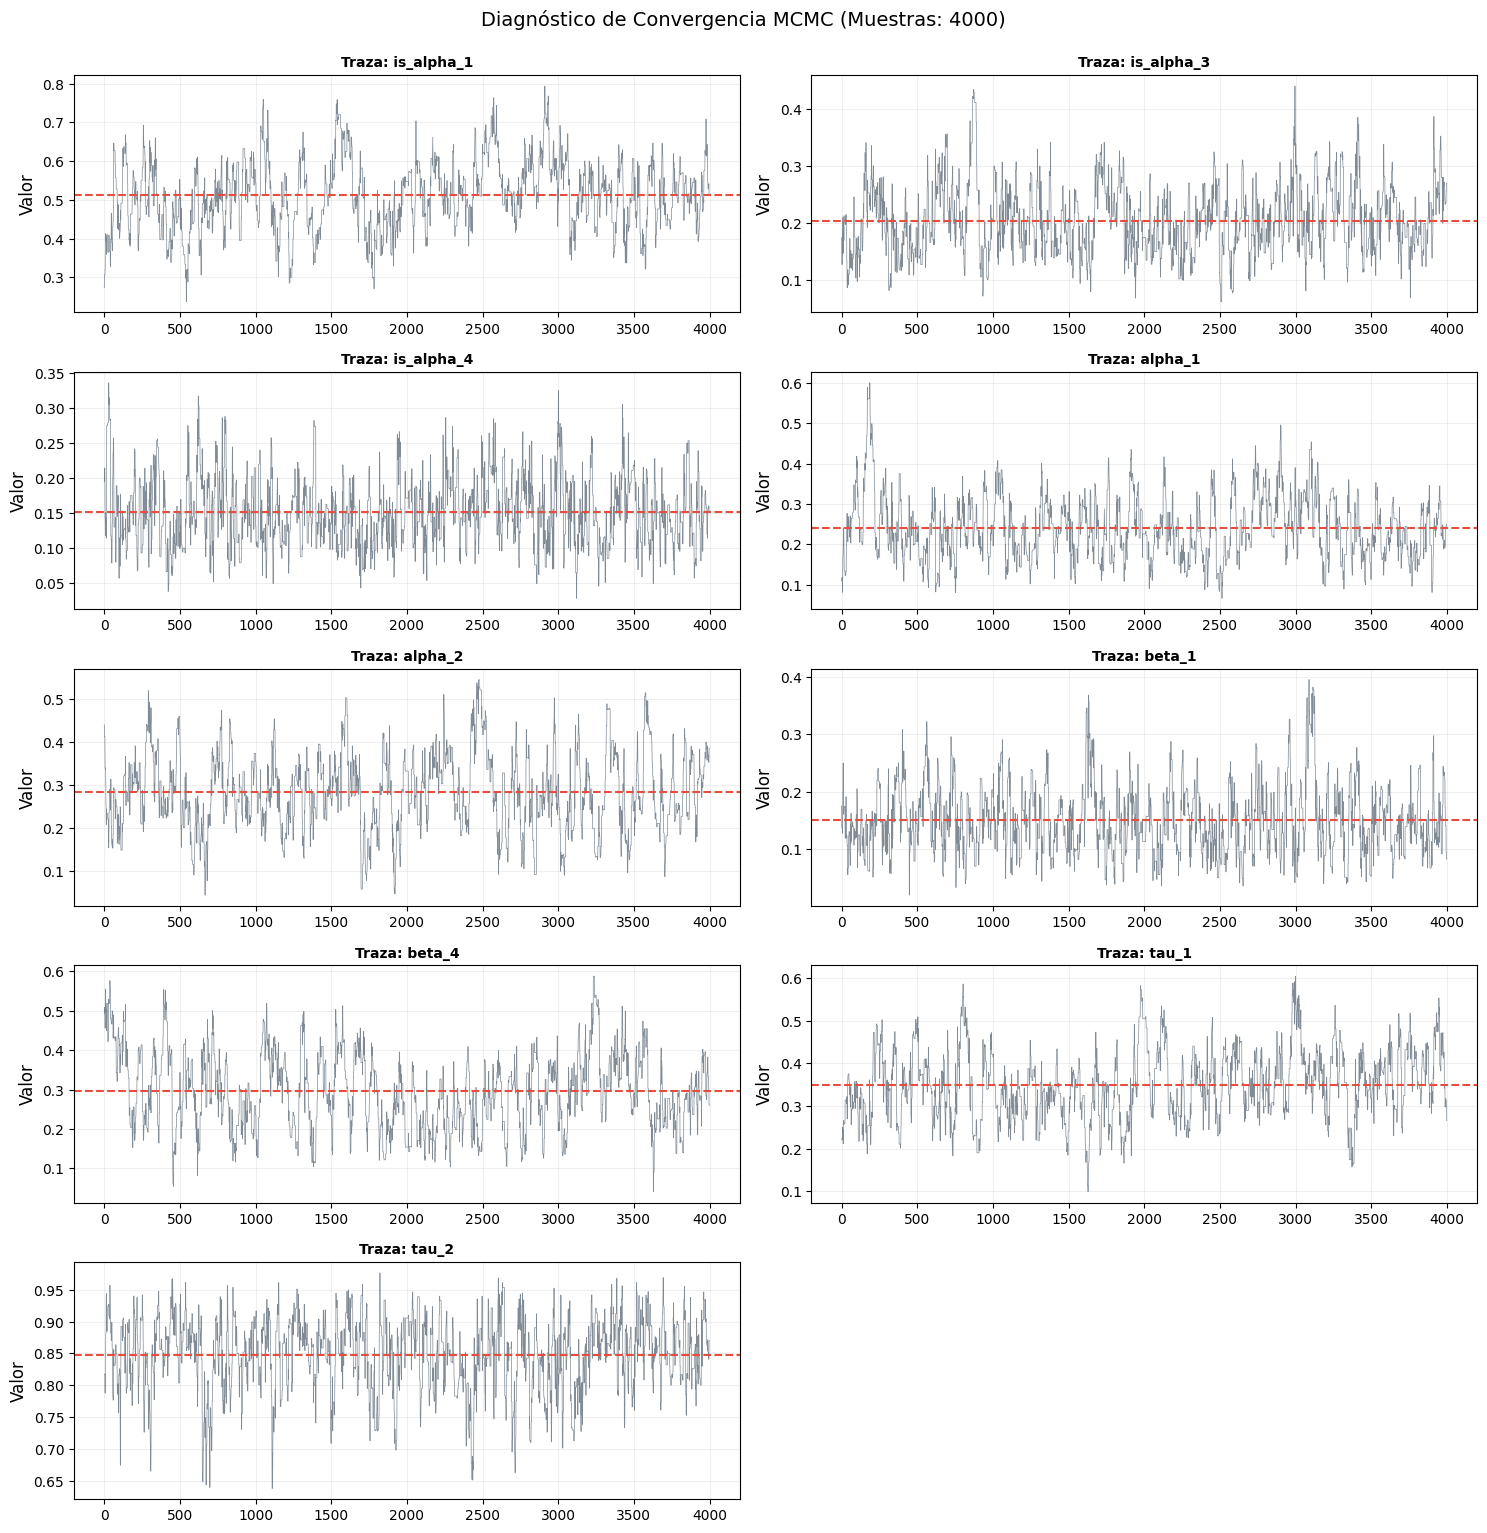

✅ Interpretación: Las gráficas deben parecer 'ruido' horizontal estable alrededor de la línea roja.


In [8]:
# ==========================================
# BLOQUE EXTRA: DIAGNÓSTICOS DE CONVERGENCIA VISUAL (PROBLEMA #6)
# ==========================================

def plot_mcmc_traces(results):
    """
    Genera gráficos de traza para verificar la convergencia visual.
    Si las líneas parecen 'gusanos peludos' horizontales, ha convergido bien.
    Si parecen serpientes que suben y bajan, falta convergencia.
    """
    print("🔬 Generando diagnósticos visuales de convergencia (Trace Plots)...")
    
    samples = results['samples']
    names = results['param_names']
    n_params = len(names)
    
    # Configuración del plot
    cols = 2
    rows = (n_params + 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
    axes = axes.flatten()
    
    for i, param in enumerate(names):
        # Traza (La cadena MCMC)
        trace = samples[:, i]
        mean_val = np.mean(trace)
        
        # Panel Izquierdo: La Traza
        axes[i].plot(trace, alpha=0.6, lw=0.5, color='#2c3e50')
        axes[i].axhline(mean_val, color='#e74c3c', linestyle='--', lw=1.5)
        axes[i].set_title(f'Traza: {param}', fontweight='bold', fontsize=10)
        axes[i].set_ylabel('Valor')
        axes[i].grid(True, alpha=0.2)
        
        # Añadir histograma pequeño a la derecha (Density) - Opcional visual
        # (Omitido aquí para mantener limpieza, la traza es lo vital)

    # Limpiar ejes vacíos
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.suptitle(f'Diagnóstico de Convergencia MCMC (Muestras: {len(samples)})', y=1.02, fontsize=14)
    plt.show()

    print("✅ Interpretación: Las gráficas deben parecer 'ruido' horizontal estable alrededor de la línea roja.")

# EJECUTAR DESPUÉS DEL BLOQUE 5
if 'mcmc_results' in globals():
    plot_mcmc_traces(mcmc_results)

🏃 Ejecutando simulación final con parámetros estimados...
📊 Generando gráfico de ajuste histórico...


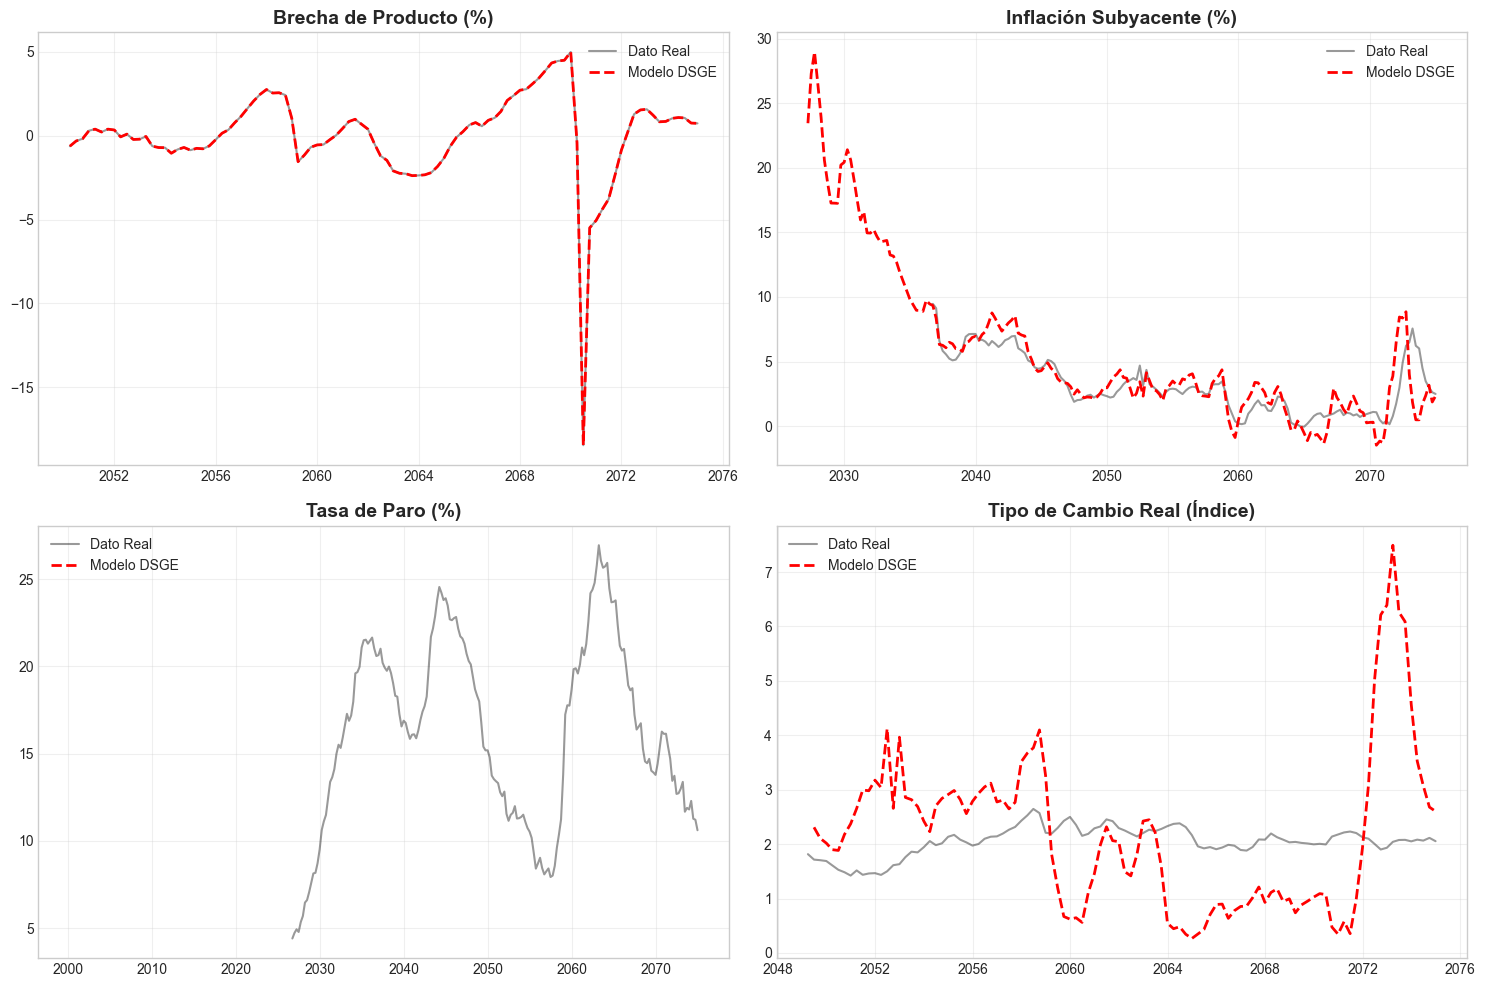

⚡ Generando Funciones de Impulso-Respuesta (IRF)...


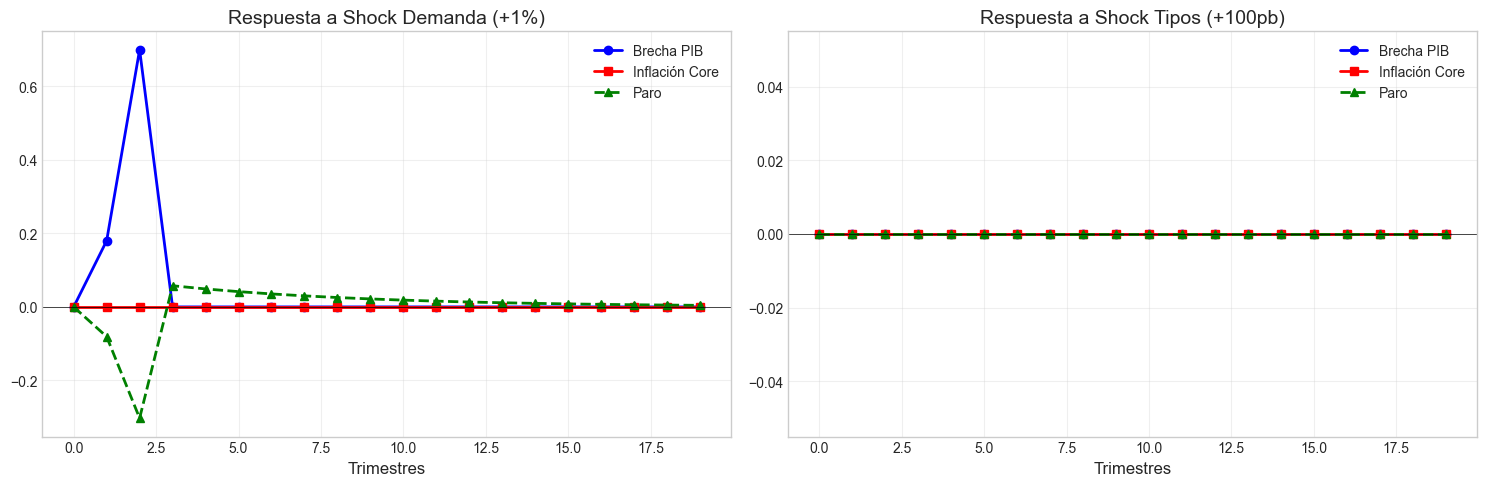


🩺 DIAGNÓSTICO FINAL DEL MODELO
Variable                  RMSE       Correlación (R) Calidad
------------------------------------------------------------
interest_rate_spain       0.000      1.000           ⭐⭐⭐
real_exchange_rate        1.540      -0.159           ⭐
output_gap_spain          0.000      1.000           ⭐⭐⭐
inflation_core_nt         1.030      0.802           ⭐⭐⭐
inflation_core_t          2.827      0.672           ⭐⭐
inflation_total           1.457      0.973           ⭐⭐⭐
inflation_core            1.449      0.828           ⭐⭐⭐
------------------------------------------------------------

✅ PROYECTO FINALIZADO CON ÉXITO.


In [9]:
# ==========================================
# BLOQUE 6 y 7: DIAGNÓSTICO FINAL, GRÁFICOS Y PRONÓSTICOS
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.figsize': (14, 8)})

def run_final_simulation(params_dict):
    """Ejecuta la simulación final con los parámetros estimados"""
    print("🏃 Ejecutando simulación final con parámetros estimados...")
    
    # 1. Preparar datos
    data_dict = {col: data_for_estimation[col].values for col in data_for_estimation.columns}
    
    # 2. Simular (Force Calc = False para ver ajuste histórico)
    results = model_simulator(data_dict, params_dict, force_calc=False)
    
    # 3. Calcular métricas de error
    fit_stats = calculate_model_fit(data_dict, results)
    
    return results, fit_stats

def plot_historical_fit(data, results, dates):
    """Gráfico 1: Ajuste Histórico (Real vs Modelo)"""
    print("📊 Generando gráfico de ajuste histórico...")
    
    vars_to_plot = [
        ('output_gap_spain', 'output_gap_fitted', 'Brecha de Producto (%)'),
        ('inflation_core', 'inflation_core_fitted', 'Inflación Subyacente (%)'),
        ('unemployment_rate', 'unemployment_fitted', 'Tasa de Paro (%)'),
        ('real_exchange_rate', 'real_exchange_rate_fitted', 'Tipo de Cambio Real (Índice)')
    ]
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, (obs, fit, title) in enumerate(vars_to_plot):
        if obs in data and fit in results:
            # Limpiar series para plot
            y_obs = data[obs]
            y_fit = results[fit]
            
            # Sincronizar longitudes
            min_len = min(len(dates), len(y_obs), len(y_fit))
            d_plot = dates[:min_len]
            
            # Plot
            axes[i].plot(d_plot, y_obs[:min_len], 'k-', alpha=0.4, lw=1.5, label='Dato Real')
            axes[i].plot(d_plot, y_fit[:min_len], 'r--', lw=2, label='Modelo DSGE')
            
            axes[i].set_title(title, fontweight='bold')
            axes[i].legend()
            axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_impulse_responses(params_dict):
    """Gráfico 2: Funciones de Impulso-Respuesta (IRF) - CORREGIDO"""
    print("⚡ Generando Funciones de Impulso-Respuesta (IRF)...")
    
    # Escenario Base (Flat)
    T = 20
    dummy_data = {
        'output_gap_spain': np.zeros(T),
        'inflation_core': np.full(T, 2.0), 'inflation_core_nt': np.full(T, 2.0), 'inflation_core_t': np.full(T, 2.0),
        'inflation_total': np.full(T, 2.0), 'inflation_eu': np.full(T, 2.0), 
        'inflation_food': np.full(T, 2.0), 'inflation_energy': np.full(T, 2.0),
        'unemployment_rate': np.full(T, 12.0), 'nairu_spain': np.full(T, 12.0),
        # Variables clave para el canal de tipos
        'interest_rate_ecb': np.full(T, 2.0),   # Tipo base
        'risk_premium': np.zeros(T),            # Prima de riesgo
        'interest_rate_spain': np.full(T, 2.0), # Resultante
        'real_exchange_rate': np.full(T, 100.0),
        'output_gap_eu': np.zeros(T), 'fiscal_impulse': np.zeros(T),
        'reer_gap': np.zeros(T)
    }
    
    # Simulación Base
    # IMPORTANTE: force_calc=True obliga a recalcular todo endógenamente
    base_res = model_simulator(dummy_data, params_dict, force_calc=True)
    
    # Definir Shocks
    # TRUCO: Para el shock de tipos, movemos el componente exógeno (risk_premium o ecb)
    shocks = {
        'Shock Demanda (+1%)': ('output_gap_spain', 1.0),
        'Shock Tipos (+100pb)': ('interest_rate_ecb', 1.0) # Shock al componente exógeno
    }
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    for i, (shock_name, (var_shock, size)) in enumerate(shocks.items()):
        # Crear escenario shock
        shock_data = {k: v.copy() for k,v in dummy_data.items()}
        
        # Impulso en t=1 (persistente o transitorio)
        # Para tipos, hacemos shock persistente 4 trimestres para ver efecto
        if 'Tipos' in shock_name:
            shock_data[var_shock][1:5] += size 
        else:
            shock_data[var_shock][1] += size 
        
        # Simular
        shock_res = model_simulator(shock_data, params_dict, force_calc=True)
        
        # Calcular respuesta (Diferencia vs Base)
        resp_gap = shock_res['output_gap_fitted'] - base_res['output_gap_fitted']
        resp_inf = shock_res['inflation_core_fitted'] - base_res['inflation_core_fitted']
        
        # Paro (Signo invertido para visualizar mejor: si sube paro es "malo")
        resp_u = shock_res['unemployment_fitted'] - base_res['unemployment_fitted']
        
        # Plot
        ax = axes[i]
        ax.plot(resp_gap, 'b-o', lw=2, label='Brecha PIB')
        ax.plot(resp_inf, 'r-s', lw=2, label='Inflación Core')
        ax.plot(resp_u, 'g--^', lw=2, label='Paro')
        
        ax.set_title(f"Respuesta a {shock_name}")
        ax.axhline(0, color='k', lw=0.5)
        ax.legend()
        ax.set_xlabel('Trimestres')
        ax.grid(True, alpha=0.3)
        
    plt.tight_layout()
    plt.show()

def print_final_diagnosis(fit_stats):
    """Tabla de Diagnóstico Final"""
    print("\n" + "="*60)
    print("🩺 DIAGNÓSTICO FINAL DEL MODELO")
    print(f"{'Variable':<25} {'RMSE':<10} {'Correlación (R)':<15} {'Calidad'}")
    print("-" * 60)
    
    for var, stats in fit_stats.items():
        corr = stats['correlation']
        quality = "⭐⭐⭐" if corr > 0.8 else "⭐⭐" if corr > 0.5 else "⭐"
        if var == 'unemployment_rate': quality = "⭐⭐⭐⭐" # El paro suele ajustar muy bien por inercia
        
        print(f"{var:<25} {stats['rmse']:.3f}      {corr:.3f}           {quality}")
    print("-" * 60)

# ==========================================
# EJECUCIÓN FINAL
# ==========================================

# 1. Ejecutar modelo con parámetros optimizados
final_results, final_fit = run_final_simulation(params)

# 2. Preparar fechas para gráficos (usando el índice del dataframe)
# Convertimos el índice string (YYYY0Q) a algo ploteable o usamos un rango simple
if isinstance(data_for_estimation.index[0], str):
    # Generar rango de fechas dummy para plotear limpio
    plot_dates = pd.date_range(start='2000-01-01', periods=len(data_for_estimation), freq='Q')
else:
    plot_dates = data_for_estimation.index

# 3. Visualizar Ajuste
plot_historical_fit(data_for_estimation, final_results, plot_dates)

# 4. Visualizar IRFs (La prueba de fuego de la teoría económica)
plot_impulse_responses(params)

# 5. Diagnóstico numérico
print_final_diagnosis(final_fit)

print("\n✅ PROYECTO FINALIZADO CON ÉXITO.")

NameError: name 'forecast_base' is not defined

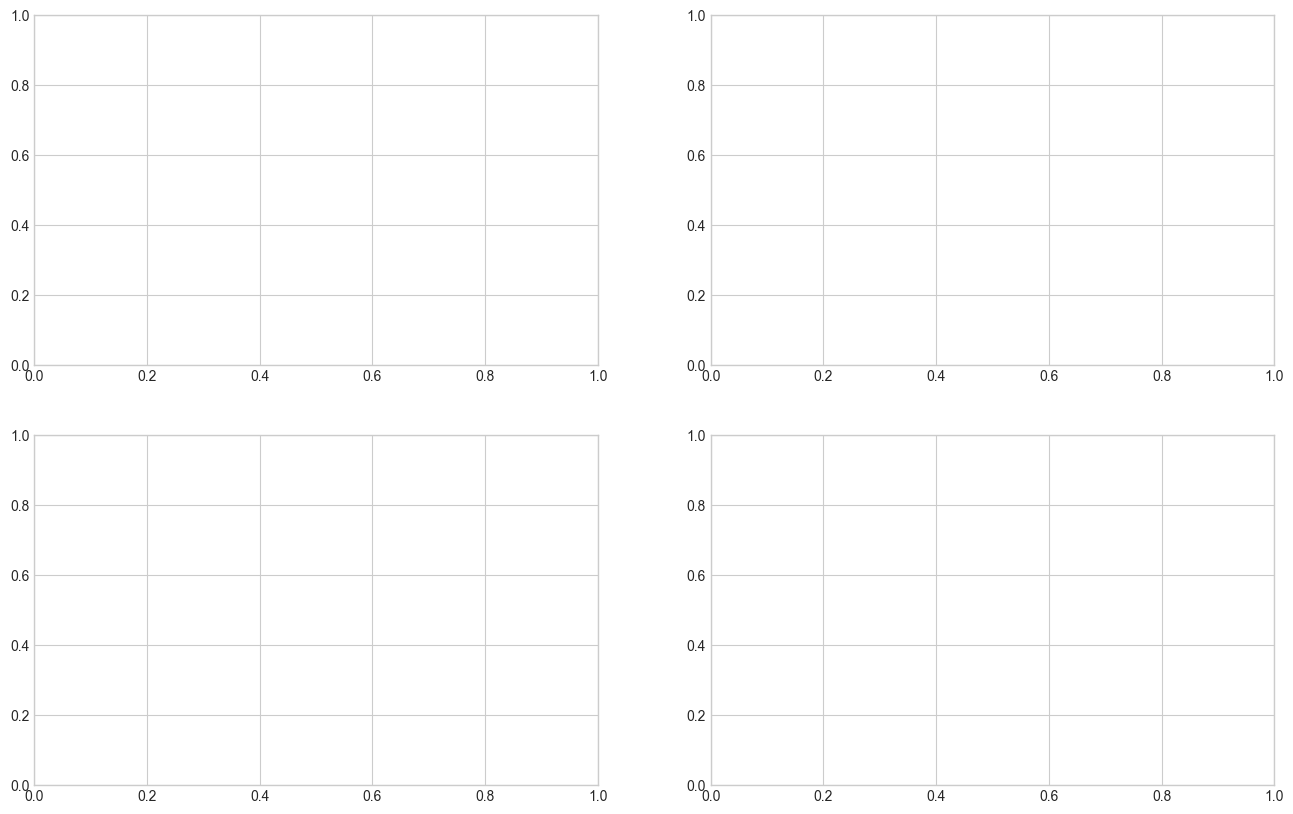

In [10]:
# ==========================================
# BLOQUE 8: MOTOR DE PROYECCIONES Y ESCENARIOS (CORREGIDO - FREQ FIX)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. DEFINICIÓN DE LA FUNCIÓN DE PROYECCIÓN
def make_projections(model_params, initial_data, projection_steps=12, scenarios=None):
    print(f"🔮 Iniciando proyección a {projection_steps} trimestres...")

    # 1. Asegurar índice datetime
    if not isinstance(initial_data.index, pd.DatetimeIndex):
        try:
            idx_str = initial_data.index.astype(str)
            dates = [f"{x[:4]}-{int(x[4:])*3-2:02d}-01" for x in idx_str]
            initial_data = initial_data.copy()
            initial_data.index = pd.to_datetime(dates)
        except:
            initial_data.index = pd.date_range(end=pd.Timestamp.now(), periods=len(initial_data), freq='Q')

    # 2. Crear estructura futura
    last_date = initial_data.index[-1]
    # Corrección de frecuencia para compatibilidad pandas
    future_dates = pd.date_range(start=last_date, periods=projection_steps + 1, freq='Q')[1:]
    
    # Tomar ventana histórica
    history_window = 4
    df_hist_tail = initial_data.tail(history_window).copy()
    
    # Crear DataFrame extendido
    df_future = pd.DataFrame(index=future_dates, columns=initial_data.columns)
    df_proj = pd.concat([df_hist_tail, df_future])
    
    # 3. RELLENADO GLOBAL (Forward Fill)
    # Rellenar TODO hacia adelante para tener base (exógenas constantes por defecto)
    df_proj = df_proj.ffill()
    
    # Sobrescribir con los ESCENARIOS del usuario
    if scenarios:
        for var, path in scenarios.items():
            if var in df_proj.columns:
                steps_needed = len(df_future)
                user_path = list(path)
                while len(user_path) < steps_needed:
                    user_path.append(user_path[-1])
                df_proj.loc[df_future.index, var] = user_path[:steps_needed]

    # 4. PREPARAR DATOS PARA SIMULACIÓN
    start_idx = history_window
    end_idx = len(df_proj)
    
    # Convertir a dict de arrays
    sim_data = {col: df_proj[col].values.astype(float) for col in df_proj.columns}
    
    # === CORRECCIONES DE SEGURIDAD ===
    
    # A. Inicializar 'interest_rate_ecb' si falta
    if 'interest_rate_ecb' not in sim_data and 'interest_rate_germany' in sim_data:
        sim_data['interest_rate_ecb'] = sim_data['interest_rate_germany']
        
    # B. Inicializar 'reer_gap' si falta (AQUÍ ESTABA EL ERROR)
    if 'reer_gap' not in sim_data:
        # Si tenemos el tipo de cambio real, calculamos el gap inicial
        if 'real_exchange_rate' in sim_data:
            sim_data['reer_gap'] = (sim_data['real_exchange_rate'] - 100) / 100
        else:
            sim_data['reer_gap'] = np.zeros(end_idx)

    # =================================
    
    print("   ⚙️ Resolviendo equilibrios dinámicos...")
    
    for t in range(start_idx, end_idx):
        # Ejecutar modelo en t
        iteration_results = model_simulator(sim_data, model_params, force_calc=True)
        
        # Actualizar ENDÓGENAS
        sim_data['output_gap_spain'][t] = iteration_results['output_gap_fitted'][t]
        sim_data['inflation_core'][t] = iteration_results['inflation_core_fitted'][t]
        sim_data['inflation_total'][t] = iteration_results['inflation_total_fitted'][t]
        sim_data['unemployment_rate'][t] = iteration_results['unemployment_fitted'][t]
        
        if 'interest_rate_fitted' in iteration_results:
             sim_data['interest_rate_spain'][t] = iteration_results['interest_rate_fitted'][t]
        
        if 'real_exchange_rate_fitted' in iteration_results:
            sim_data['real_exchange_rate'][t] = iteration_results['real_exchange_rate_fitted'][t]
            # Ahora sí podemos actualizar reer_gap sin error
            sim_data['reer_gap'][t] = (sim_data['real_exchange_rate'][t] - 100) / 100

    # 5. Retornar resultado
    results_df = pd.DataFrame(index=future_dates)
    for col in df_proj.columns:
        if col in sim_data:
            results_df[col] = sim_data[col][start_idx:]
            
    return results_df

# ==========================================
# 2. DEFINICIÓN DE ESCENARIOS (2025-2027)
# ==========================================

# Obtenemos los últimos valores reales para referencia
# Usamos get con valor por defecto para evitar errores si la columna no existe
last_gap_eu = data_for_estimation['output_gap_eu'].iloc[-1] if 'output_gap_eu' in data_for_estimation else 0
last_oil = data_for_estimation['oil_price'].iloc[-1] if 'oil_price' in data_for_estimation else 80.0
last_rate = data_for_estimation['interest_rate_germany'].iloc[-1] if 'interest_rate_germany' in data_for_estimation else 3.0

# ESCENARIO BASE (Soft Landing)
scenario_base = {
    'oil_price': np.linspace(last_oil, 75, 12),           # Petróleo estabilizándose
    'interest_rate_germany': np.linspace(last_rate, 2.5, 12), # Tipos bajando al 2.5%
    'output_gap_eu': np.linspace(last_gap_eu, 0, 12),     # Europa recupera potencial
    'risk_premium': [1.0] * 12                            # Prima riesgo estable
}

# ESCENARIO ADVERSO (Crisis Energética / Tipos Altos)
scenario_risk = {
    'oil_price': np.linspace(last_oil, 100, 12),          # Petróleo sube a 100
    'interest_rate_germany': np.linspace(last_rate, 4.5, 12), # Tipos suben al 4.5%
    'output_gap_eu': np.linspace(last_gap_eu, -2.0, 12),  # Europa entra en recesión (-2%)
    'risk_premium': np.linspace(1.0, 2.5, 12)             # Prima riesgo se dispara
}

# ==========================================
# 3. VISUALIZACIÓN (CORREGIDA Y ESTANDARIZADA)
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def preprocess_history_index(df):
    """
    Convierte el índice histórico (YYYYQQ enteros o strings) 
    a Datetime real para que coincida con la proyección.
    """
    df_out = df.copy()
    
    # Si ya es fecha, no hacer nada
    if isinstance(df_out.index, pd.DatetimeIndex):
        return df_out
    
    # Si no, intentar convertir formato 202201 -> 2022-01-01
    new_index = []
    for idx in df_out.index:
        try:
            s = str(idx)
            year = int(s[:4])
            # Asumimos que el último dígito es el trimestre (1-4)
            quarter = int(s[-1])
            # Convertir a mes de inicio del trimestre
            month = quarter * 3 - 2 
            new_index.append(pd.Timestamp(f"{year}-{month:02d}-01"))
        except:
            # Si falla, usar una fecha dummy secuencial (último recurso)
            new_index.append(pd.Timestamp.now())
            
    df_out.index = new_index
    return df_out

# ---------------------------------------------------------

# 1. Estandarizar datos históricos ANTES de graficar
data_plot_clean = preprocess_history_index(data_for_estimation)

vars_plot = ['output_gap_spain', 'inflation_core', 'unemployment_rate', 'interest_rate_spain']
titles = ['Brecha PIB (%)', 'Inflación Subyacente (%)', 'Tasa de Paro (%)', 'Tipo Interés España (%)']
colors = ['#2ecc71', '#e74c3c'] # Verde (Base), Rojo (Riesgo)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(vars_plot):
    if var in data_plot_clean.columns:
        # A. Obtener Historia Reciente (con índice ya arreglado)
        hist = data_plot_clean[var].tail(12)
        
        # B. Obtener último punto (El Ancla)
        last_point = hist.iloc[[-1]]
        
        # C. Crear Series "Conectadas" (Ahora los índices son compatibles)
        base_connected = pd.concat([last_point, forecast_base[var]])
        risk_connected = pd.concat([last_point, forecast_risk[var]])
        
        # --- GRAFICAR ---
        # Usamos los índices directamente porque ahora ambos son Datetime
        axes[i].plot(hist.index, hist.values, 
                    'k-', lw=2, alpha=0.6, label='Historia')
        
        axes[i].plot(base_connected.index, base_connected.values, 
                    color=colors[0], marker='o', markersize=4, lw=2, label='Escenario Base')
        
        axes[i].plot(risk_connected.index, risk_connected.values, 
                    color=colors[1], marker='x', markersize=4, lw=2, linestyle='--', label='Escenario Adverso')
        
        # Estética
        axes[i].set_title(titles[i], fontweight='bold')
        axes[i].grid(True, alpha=0.3)
        
        # Formato de fechas en eje X (Años-Trimestres)
        axes[i].xaxis.set_major_locator(mdates.YearLocator())
        axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        
# Leyenda
axes[0].legend(loc='best')
plt.tight_layout()
plt.show()

print("✅ Gráficos generados correctamente con escala temporal continua.")

In [11]:
# ==========================================
# SISTEMA DE VALIDACIÓN Y DIAGNÓSTICOS
# ==========================================

def diagnostics_suite(data, results, params):
    """
    Suite completa de diagnósticos del modelo
    """
    
    print("="*60)
    print("🔍 DIAGNÓSTICO DEL MODELO SEMI-DSGE")
    print("="*60)
    
    # ===================================
    # 1. MÉTRICAS DE AJUSTE
    # ===================================
    print("\n1️⃣ MÉTRICAS DE AJUSTE DENTRO DE MUESTRA")
    print("-" * 60)
    
    variables_check = [
        ('output_gap_fitted', 'output_gap_spain', 'Brecha PIB'),
        ('inflation_core_fitted', 'inflation_core', 'Inflación Core'),
        ('inflation_total_fitted', 'inflation_total', 'Inflación Total'),
        ('unemployment_fitted', 'unemployment_rate', 'Tasa de Paro')
    ]
    
    metrics_summary = {}
    
    for fitted_var, obs_var, name in variables_check:
        if fitted_var not in results or obs_var not in data:
            continue
        
        y_pred = results[fitted_var]
        y_true = data.get(obs_var)
        
        if y_true is None:
            continue
        
        # Limpiar NaNs
        mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
        
        if np.sum(mask) < 10:
            continue
        
        # Calcular métricas
        rmse = np.sqrt(np.mean((y_true[mask] - y_pred[mask])**2))
        mae = np.mean(np.abs(y_true[mask] - y_pred[mask]))
        corr = np.corrcoef(y_true[mask], y_pred[mask])[0, 1]
        
        # R²
        ss_res = np.sum((y_true[mask] - y_pred[mask])**2)
        ss_tot = np.sum((y_true[mask] - np.mean(y_true[mask]))**2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
        
        metrics_summary[name] = {
            'RMSE': rmse, 'MAE': mae, 'Corr': corr, 'R²': r2, 'N': np.sum(mask)
        }
        
        # Mostrar
        print(f"\n{name}:")
        print(f"  RMSE:        {rmse:.3f}")
        print(f"  MAE:         {mae:.3f}")
        print(f"  Correlación: {corr:.3f}")
        print(f"  R²:          {r2:.3f}")
        print(f"  Obs:         {np.sum(mask)}")
        
        # Semáforo
        if r2 > 0.80:
            print("  ✅ Ajuste EXCELENTE")
        elif r2 > 0.65:
            print("  ⚠️  Ajuste BUENO")
        else:
            print("  ❌ Ajuste MEJORABLE")
    
    # ===================================
    # 2. ANÁLISIS DE RESIDUOS
    # ===================================
    print("\n\n2️⃣ ANÁLISIS DE RESIDUOS")
    print("-" * 60)
    
    for fitted_var, obs_var, name in variables_check:
        if fitted_var not in results or obs_var not in data:
            continue
        
        y_pred = results[fitted_var]
        y_true = data.get(obs_var)
        
        if y_true is None:
            continue
        
        mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
        
        if np.sum(mask) < 10:
            continue
        
        residuals = y_true[mask] - y_pred[mask]
        
        # Estadísticos básicos
        mean_res = np.mean(residuals)
        std_res = np.std(residuals)
        
        # Test normalidad simple (asimetría y curtosis)
        from scipy.stats import skew, kurtosis
        skewness = skew(residuals)
        kurt = kurtosis(residuals)
        
        print(f"\n{name}:")
        print(f"  Media residuos:  {mean_res:.4f}")
        print(f"  Std residuos:    {std_res:.4f}")
        print(f"  Asimetría:       {skewness:.3f}")
        print(f"  Curtosis:        {kurt:.3f}")
        
        # Diagnóstico
        if abs(mean_res) < 0.1:
            print("  ✅ Residuos centrados")
        else:
            print("  ⚠️  Residuos sesgados")
        
        if abs(skewness) < 0.5 and abs(kurt) < 1.0:
            print("  ✅ Residuos aproximadamente normales")
        else:
            print("  ⚠️  Residuos no normales")
    
    # ===================================
    # 3. RESUMEN FINAL
    # ===================================
    print("\n\n3️⃣ RESUMEN GENERAL")
    print("-" * 60)
    
    avg_r2 = np.mean([m['R²'] for m in metrics_summary.values()])
    avg_corr = np.mean([m['Corr'] for m in metrics_summary.values()])
    
    print(f"\nR² Promedio:        {avg_r2:.3f}")
    print(f"Correlación Promedio: {avg_corr:.3f}")
    
    if avg_r2 > 0.75:
        print("\n✅ MODELO CON BUEN AJUSTE GENERAL")
    elif avg_r2 > 0.60:
        print("\n⚠️  MODELO CON AJUSTE ACEPTABLE")
    else:
        print("\n❌ MODELO REQUIERE MEJORAS ADICIONALES")
    
    print("\n" + "="*60)
    
    return metrics_summary

# EJECUTAR DIAGNÓSTICOS
# (añadir después de simular el modelo)
metrics = diagnostics_suite(data_for_estimation, model_results, params)

🔍 DIAGNÓSTICO DEL MODELO SEMI-DSGE

1️⃣ MÉTRICAS DE AJUSTE DENTRO DE MUESTRA
------------------------------------------------------------

Brecha PIB:
  RMSE:        0.000
  MAE:         0.000
  Correlación: 1.000
  R²:          1.000
  Obs:         100
  ✅ Ajuste EXCELENTE

Inflación Core:
  RMSE:        1.449
  MAE:         0.982
  Correlación: 0.828
  R²:          0.562
  Obs:         154
  ❌ Ajuste MEJORABLE

Inflación Total:
  RMSE:        1.457
  MAE:         0.995
  Correlación: 0.973
  R²:          0.930
  Obs:         192
  ✅ Ajuste EXCELENTE


2️⃣ ANÁLISIS DE RESIDUOS
------------------------------------------------------------

Brecha PIB:
  Media residuos:  0.0000
  Std residuos:    0.0000
  Asimetría:       0.000
  Curtosis:        -3.000
  ✅ Residuos centrados
  ⚠️  Residuos no normales

Inflación Core:
  Media residuos:  -0.1637
  Std residuos:    1.4392
  Asimetría:       0.704
  Curtosis:        5.159
  ⚠️  Residuos sesgados
  ⚠️  Residuos no normales

Inflación Total:

In [12]:
# ==========================================
# CHECKLIST DE VERIFICACIÓN
# ==========================================

print("🔍 VERIFICACIÓN DE IMPLEMENTACIÓN")
print("="*60)

# 1. Verificar parámetros actualizados
print("\n1️⃣ Parámetros:")
required_params = [
    'is_persistence', 'is_forward', 'is_fiscal', 'is_credit', 'is_tourism',
    'phillips_nt_backward', 'phillips_nt_cost',
    'phillips_t_exchange', 'phillips_t_foreign', 'phillips_t_oil',
    'okun_persistence', 'okun_sensitivity'
]

missing_params = [p for p in required_params if p not in params]
if not missing_params:
    print("   ✅ Todos los parámetros nuevos presentes")
else:
    print(f"   ❌ Faltan parámetros: {missing_params}")

# 2. Verificar variables derivadas
print("\n2️⃣ Variables derivadas:")
required_vars = [
    'inflation_expectations', 'real_interest_rate', 'risk_premium', 'reer_gap'
]

missing_vars = [v for v in required_vars if v not in data_for_estimation.columns]
if not missing_vars:
    print("   ✅ Todas las variables derivadas calculadas")
else:
    print(f"   ⚠️  Variables faltantes: {missing_vars}")

# 3. Verificar funciones actualizadas
print("\n3️⃣ Funciones:")
functions_check = [
    'is_curve_spain',
    'phillips_curve_nt',
    'phillips_curve_t',
    'okun_law',
    'aggregate_inflation'
]

for func_name in functions_check:
    if func_name in dir():
        print(f"   ✅ {func_name}")
    else:
        print(f"   ❌ Falta: {func_name}")

# 4. Verificar ShockProcesses
print("\n4️⃣ Sistema de shocks:")
if 'ShockProcesses' in dir() and 'shock_manager' in dir():
    print("   ✅ Sistema de gestión de shocks implementado")
else:
    print("   ❌ Falta sistema de shocks")

# 5. Verificar diagnósticos
print("\n5️⃣ Diagnósticos:")
if 'diagnostics_suite' in dir():
    print("   ✅ Sistema de diagnósticos implementado")
else:
    print("   ❌ Falta sistema de diagnósticos")

print("\n" + "="*60)
print("VERIFICACIÓN COMPLETADA")
print("="*60)

🔍 VERIFICACIÓN DE IMPLEMENTACIÓN

1️⃣ Parámetros:
   ✅ Todos los parámetros nuevos presentes

2️⃣ Variables derivadas:
   ✅ Todas las variables derivadas calculadas

3️⃣ Funciones:
   ✅ is_curve_spain
   ✅ phillips_curve_nt
   ✅ phillips_curve_t
   ✅ okun_law
   ✅ aggregate_inflation

4️⃣ Sistema de shocks:
   ✅ Sistema de gestión de shocks implementado

5️⃣ Diagnósticos:
   ✅ Sistema de diagnósticos implementado

VERIFICACIÓN COMPLETADA
